# **VISUALIZATIONS METHODOLOGY**

1. Metric Summary: Accuracy and AUC
This grouped bar chart visualizes the mean Classification Accuracy and the Area Under the Receiver Operating Characteristic Curve (AUC-ROC) for each model. Error bars represent the standard deviation ($\pm 1$ SD) across $k$-fold cross-validation, satisfying the requirement to report point estimates with corresponding variance metrics. Empirical $p$-values derived from permutation testing ($n=1000$) are annotated to establish the statistical significance of the decoding performance against chance levels.  

2. Normalized Confusion Matrices
Confusion matrices are computed for each model and normalized by the true class support. This visualization explicitly displays the True Positive Rate (Sensitivity) on the valid syntax class and True Negative Rate (Specificity) on the invalid syntax class. Reporting these metrics is mandated for rigorous biomedical predictive modeling to evaluate potential biases toward the majority class.  

3. Receiver Operating Characteristic (ROC) Curves
The ROC curve plots the True Positive Rate against the False Positive Rate across varying decision thresholds. For $k$-fold cross-validation, the mean ROC curve is plotted alongside a shaded region representing $\pm 1$ standard deviation. This illustrates the variance in decision boundaries and provides a comprehensive view of model stability


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
from google.colab import drive

In [ ]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

In [ ]:
drive.mount('/content/drive')
INTER_DIR = '/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data'
FIG_DIR = os.path.join(INTER_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}\n")

print(f"Drive mounted. Target base directory: {INTER_DIR}")
print(f"Directory exists: {os.path.exists(INTER_DIR)}")

Mounted at /content/drive
Figures will be saved to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/figures

Drive mounted. Target base directory: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data
Directory exists: True


In [ ]:
import os
import pandas as pd
import pickle

# defining file paths
results_csv_path = os.path.join(INTER_DIR, 'results_table.csv')
viz_data_path = os.path.join(INTER_DIR, 'export_metrics.pkl')

# loading and verifying the Aggregated Metrics
try:
    df_inter_results = pd.read_csv(results_csv_path)
    print("--- Aggregated Metrics CSV ---")
    print(df_inter_results.head())
    print(f"\nCSV Columns: {df_inter_results.columns.tolist()}")
except FileNotFoundError:
    print(f"CRITICAL ERROR: Could not find {results_csv_path}. Please check the mount and path.")

# loading and verifying the visualisation data in .pkl
try:
    with open(viz_data_path, 'rb') as f:
        viz_data = pickle.load(f)
    print("\n--- Visualization PKL File ---")

    print(f"Primary Keys: {list(viz_data.keys())}")

    first_key = list(viz_data.keys())[0]
    print(f"\nInspecting structure for top-level key: '{first_key}'")

    if isinstance(viz_data[first_key], dict):
         for sub_key, value in viz_data[first_key].items():
            if isinstance(value, dict):
                 print(f"  -> '{sub_key}': nested dictionary with keys {list(value.keys())}")
            elif isinstance(value, list):
                print(f"  -> '{sub_key}': list of length {len(value)}")
            elif hasattr(value, 'shape'):
                print(f"  -> '{sub_key}': numpy array of shape {value.shape}")
            else:
                print(f"  -> '{sub_key}': {type(value)}")
    else:
         print(f"  Type: {type(viz_data[first_key])}")

except FileNotFoundError:
    print(f"CRITICAL ERROR: Could not find {viz_data_path}. Please check the mount and path.")

--- Aggregated Metrics CSV ---
   Cohort          Model  Mean_Accuracy     STD  P-Value  Significant  \
0  Global            LDA         0.5667  0.0698    0.001         True   
1  Global     SVM-Linear         0.5636  0.0700    0.001         True   
2  Global        SVM-RBF         0.5683  0.0757    0.001         True   
3  Global  Random Forest         0.5650  0.0723    0.001         True   
4  Global            MLP         0.5661  0.0629    0.001         True   

                                     Hyperparameters  
0  {'covariance_estimator': None, 'n_components':...  
1  {'C': 0.001, 'break_ties': False, 'cache_size'...  
2  {'C': 0.01, 'break_ties': False, 'cache_size':...  
3  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...  
4  {'activation': 'relu', 'alpha': 0.01, 'batch_s...  

CSV Columns: ['Cohort', 'Model', 'Mean_Accuracy', 'STD', 'P-Value', 'Significant', 'Hyperparameters']

--- Visualization PKL File ---
Primary Keys: ['Global', 'Novices', 'Experts']

Inspecting struct

## 1. INTER-SUBJECT CLASSIFICATION GLOBAL

In [ ]:
def generate_global_summary_table(df):
    df_global = df[df['Cohort'] == 'Global'].copy()

    # selecting relevant data
    summary_table = df_global[['Model', 'Mean_Accuracy', 'STD', 'P-Value', 'Significant']].copy()

    summary_table['Mean_Accuracy'] = (summary_table['Mean_Accuracy'] * 100).map('{:.2f}%'.format)
    summary_table['STD'] = (summary_table['STD'] * 100).map('{:.2f}%'.format)

    # p-value for presentation
    summary_table['P-Value'] = summary_table['P-Value'].map('{:.3f}'.format)

    print("--- Global Cohort Performance Summary ---")
    print(summary_table.to_markdown(index=False))

    # EXPORT CSV
    '''table_path = os.path.join(FIG_DIR, 'Table1_Global_Performance.csv')
    summary_table.to_csv(table_path, index=False)
    print(f"\nSaved table to: {table_path}")'''

# Execute
generate_global_summary_table(df_inter_results)

--- Global Cohort Performance Summary ---
| Model         | Mean_Accuracy   | STD   |   P-Value | Significant   |
|:--------------|:----------------|:------|----------:|:--------------|
| LDA           | 56.67%          | 6.98% |     0.001 | True          |
| SVM-Linear    | 56.36%          | 7.00% |     0.001 | True          |
| SVM-RBF       | 56.83%          | 7.57% |     0.001 | True          |
| Random Forest | 56.50%          | 7.23% |     0.001 | True          |
| MLP           | 56.61%          | 6.29% |     0.001 | True          |


## 2. INTER-SUB CLASSIFICATION BY EXPERTISE

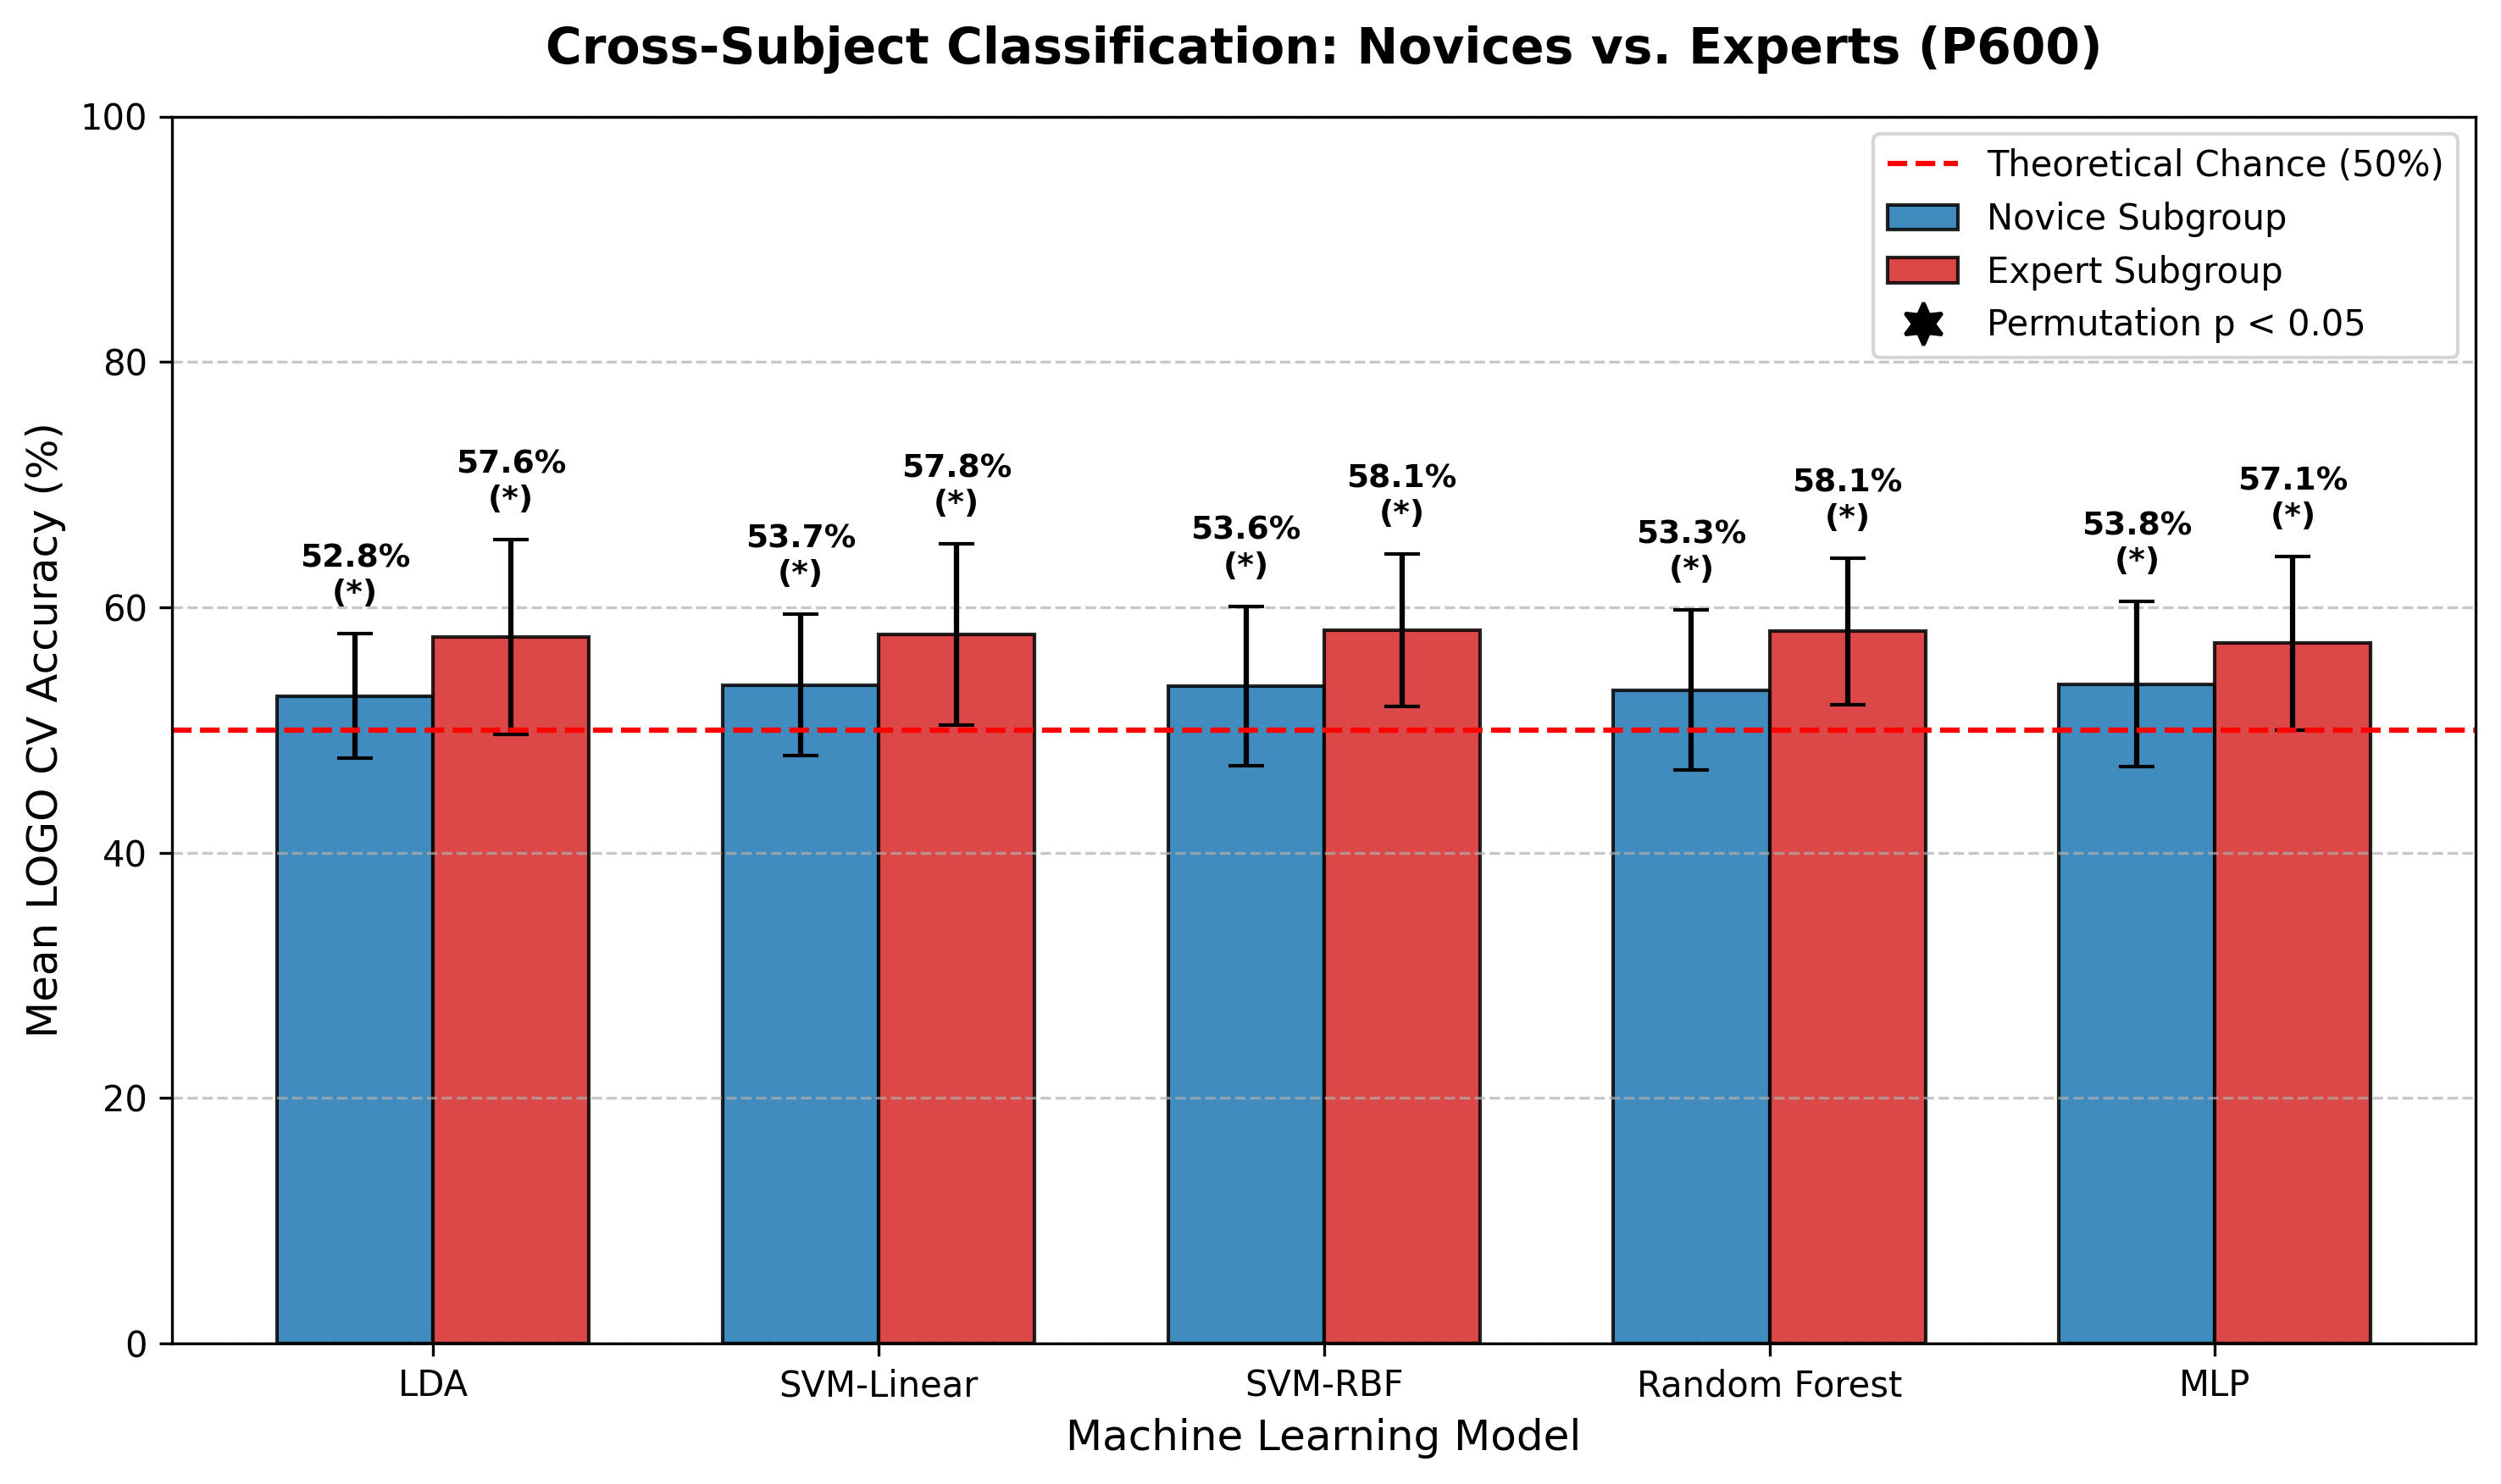

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.lines as mlines
import os

def plot_expertise_inter_subject(df, save_dir):
    # filtering out the subgroups
    df_exp = df[df['Cohort'].isin(['Novices', 'Experts'])].copy()

    # scaling metrics
    df_exp['Mean_Accuracy'] = df_exp['Mean_Accuracy'] * 100
    df_exp['STD'] = df_exp['STD'] * 100

    # SETUP CANVAS
    fig, ax = plt.subplots(figsize=(10, 6))

    models = df_exp['Model'].unique()
    x_pos = np.arange(len(models))
    bar_width = 0.35

    # color maps
    colors = {'Novices': '#1f78b4', 'Experts': '#d62728'}
    labels_map = {'Novices': 'Novice Subgroup', 'Experts': 'Expert Subgroup'}

    # iteratively plot Novices then Experts
    for i, cohort in enumerate(['Novices', 'Experts']):
        cohort_data = df_exp[df_exp['Cohort'] == cohort]
        cohort_data = cohort_data.set_index('Model').reindex(models).reset_index()

        offset = (i - 0.5) * bar_width

        bars = ax.bar(x_pos + offset, cohort_data['Mean_Accuracy'], bar_width,
                      yerr=cohort_data['STD'], capsize=5,
                      label=labels_map[cohort], color=colors[cohort],
                      edgecolor='black', alpha=0.85)

        # annotations
        for j, bar in enumerate(bars):
            acc_val = cohort_data['Mean_Accuracy'].iloc[j]
            std_val = cohort_data['STD'].iloc[j]
            is_sig = cohort_data['Significant'].iloc[j]

            y_text = acc_val + std_val + 2

            sig_text = "(*)" if is_sig else ""

            annotation_text = f"{acc_val:.1f}%\n{sig_text}"
            ax.text(bar.get_x() + bar.get_width()/2, y_text,
                    annotation_text, ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='black')

    # formatting and thresholds
    ax.set_ylabel('Mean LOGO CV Accuracy (%)')
    ax.set_xlabel('Machine Learning Model')
    ax.set_title('Cross-Subject Classification: Novices vs. Experts (P600)', fontweight='bold', pad=15)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 100)

    ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Theoretical Chance (50%)')

    # LEGEND
    handles, labels = ax.get_legend_handles_labels()

    sig_marker = mlines.Line2D([], [], color='none', marker=(6, 1, 0),
                               markersize=12, markerfacecolor='black', markeredgecolor='black')
    handles.append(sig_marker)
    labels.append('Permutation p < 0.05')

    ax.legend(handles=handles, labels=labels, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()

    # 8. Export Logic
    '''fig_path = os.path.join(save_dir, 'inter-sub_expertise.png')
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')'''
    plt.show()

    #print(f"Saved to: {fig_path}")

# Execute
plot_expertise_inter_subject(df_inter_results, FIG_DIR)

## 3. Confusion-Matrix (per model)

--- Generating Individual Confusion Matrices for Global Cohort ---
Model: LDA | Final Array Shape: (2, 2) | Subjects: 45


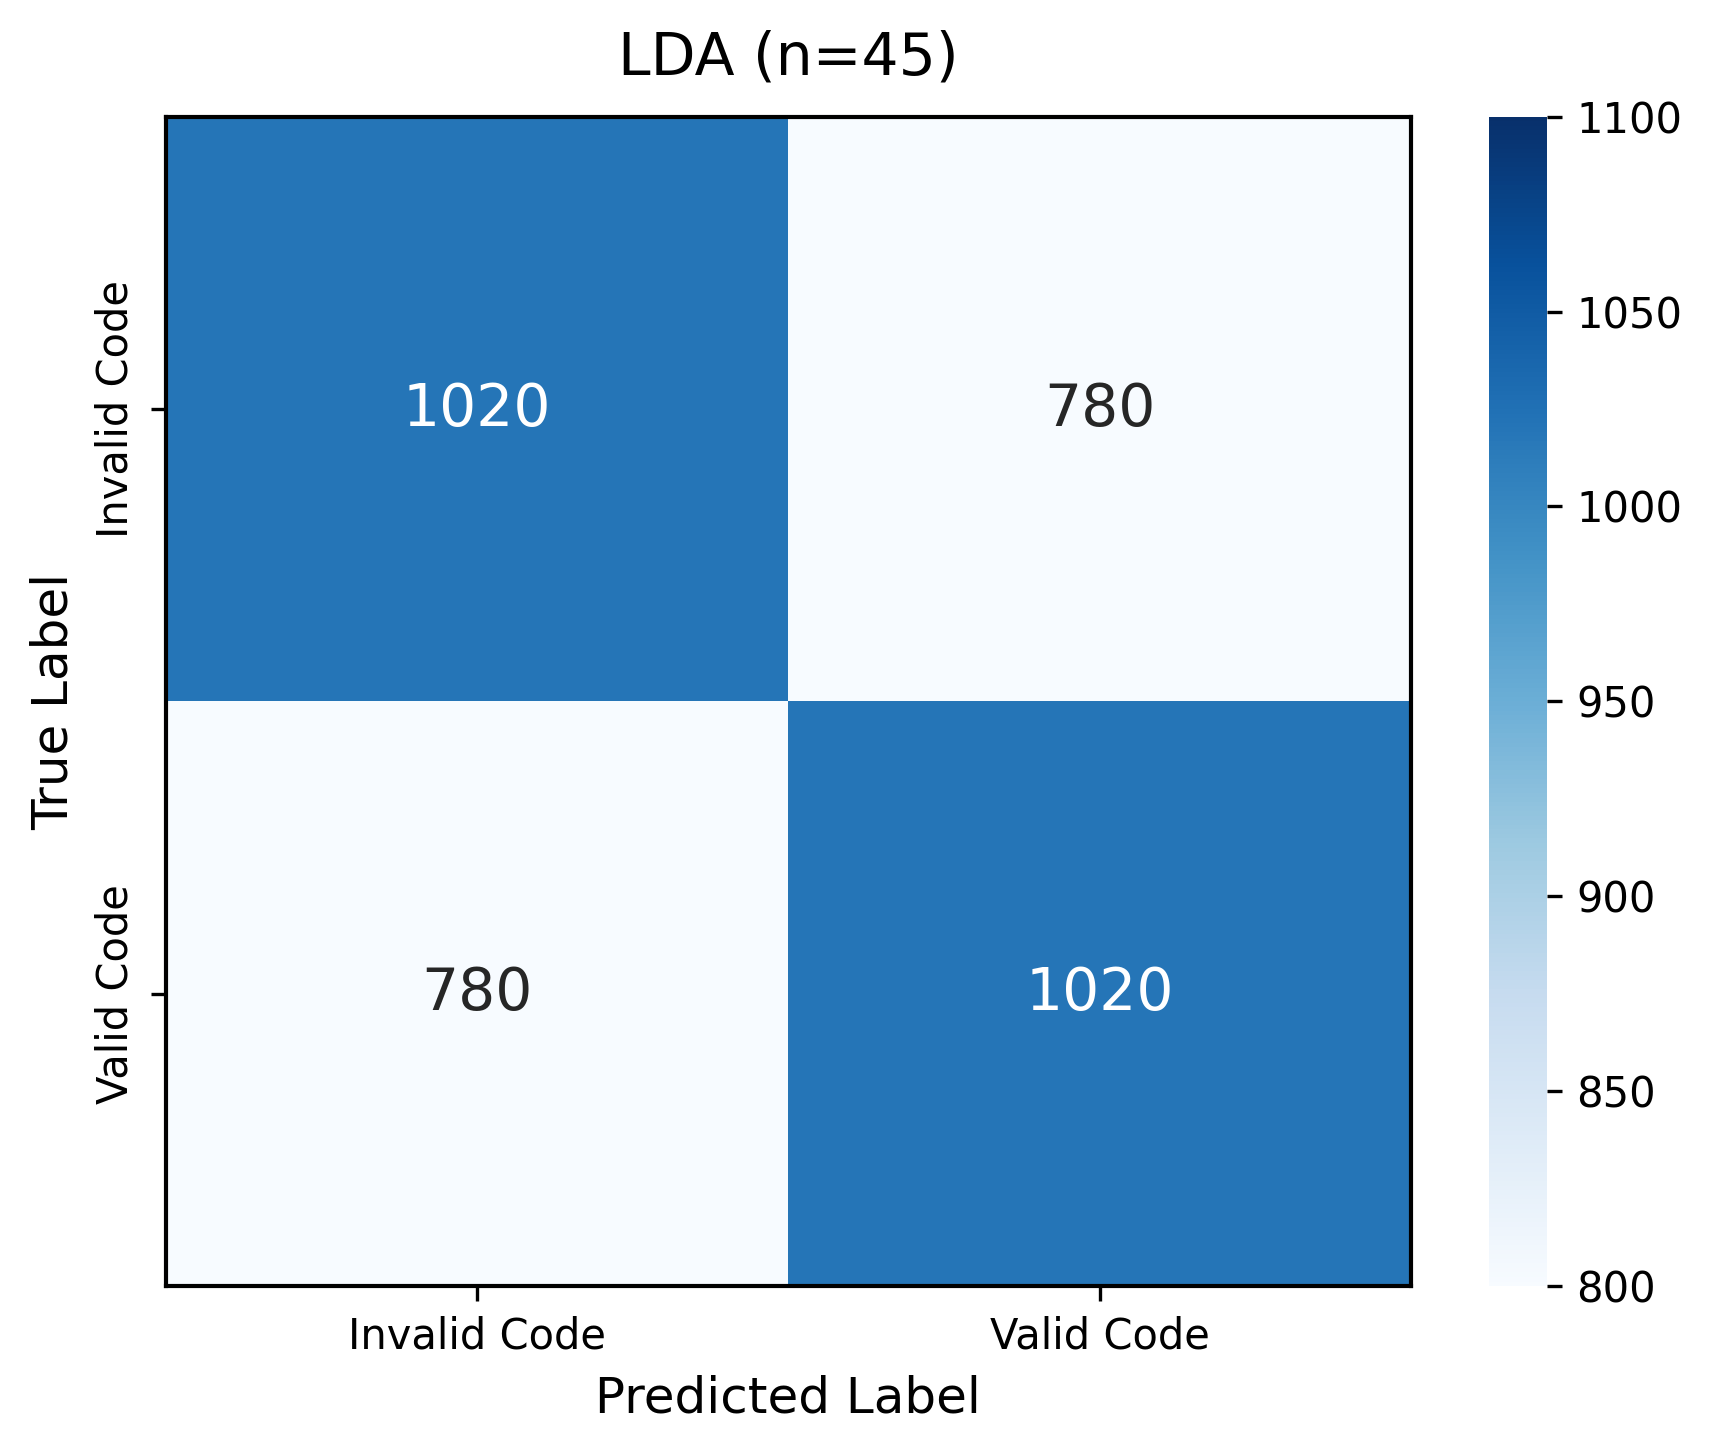

Model: SVM-Linear | Final Array Shape: (2, 2) | Subjects: 45


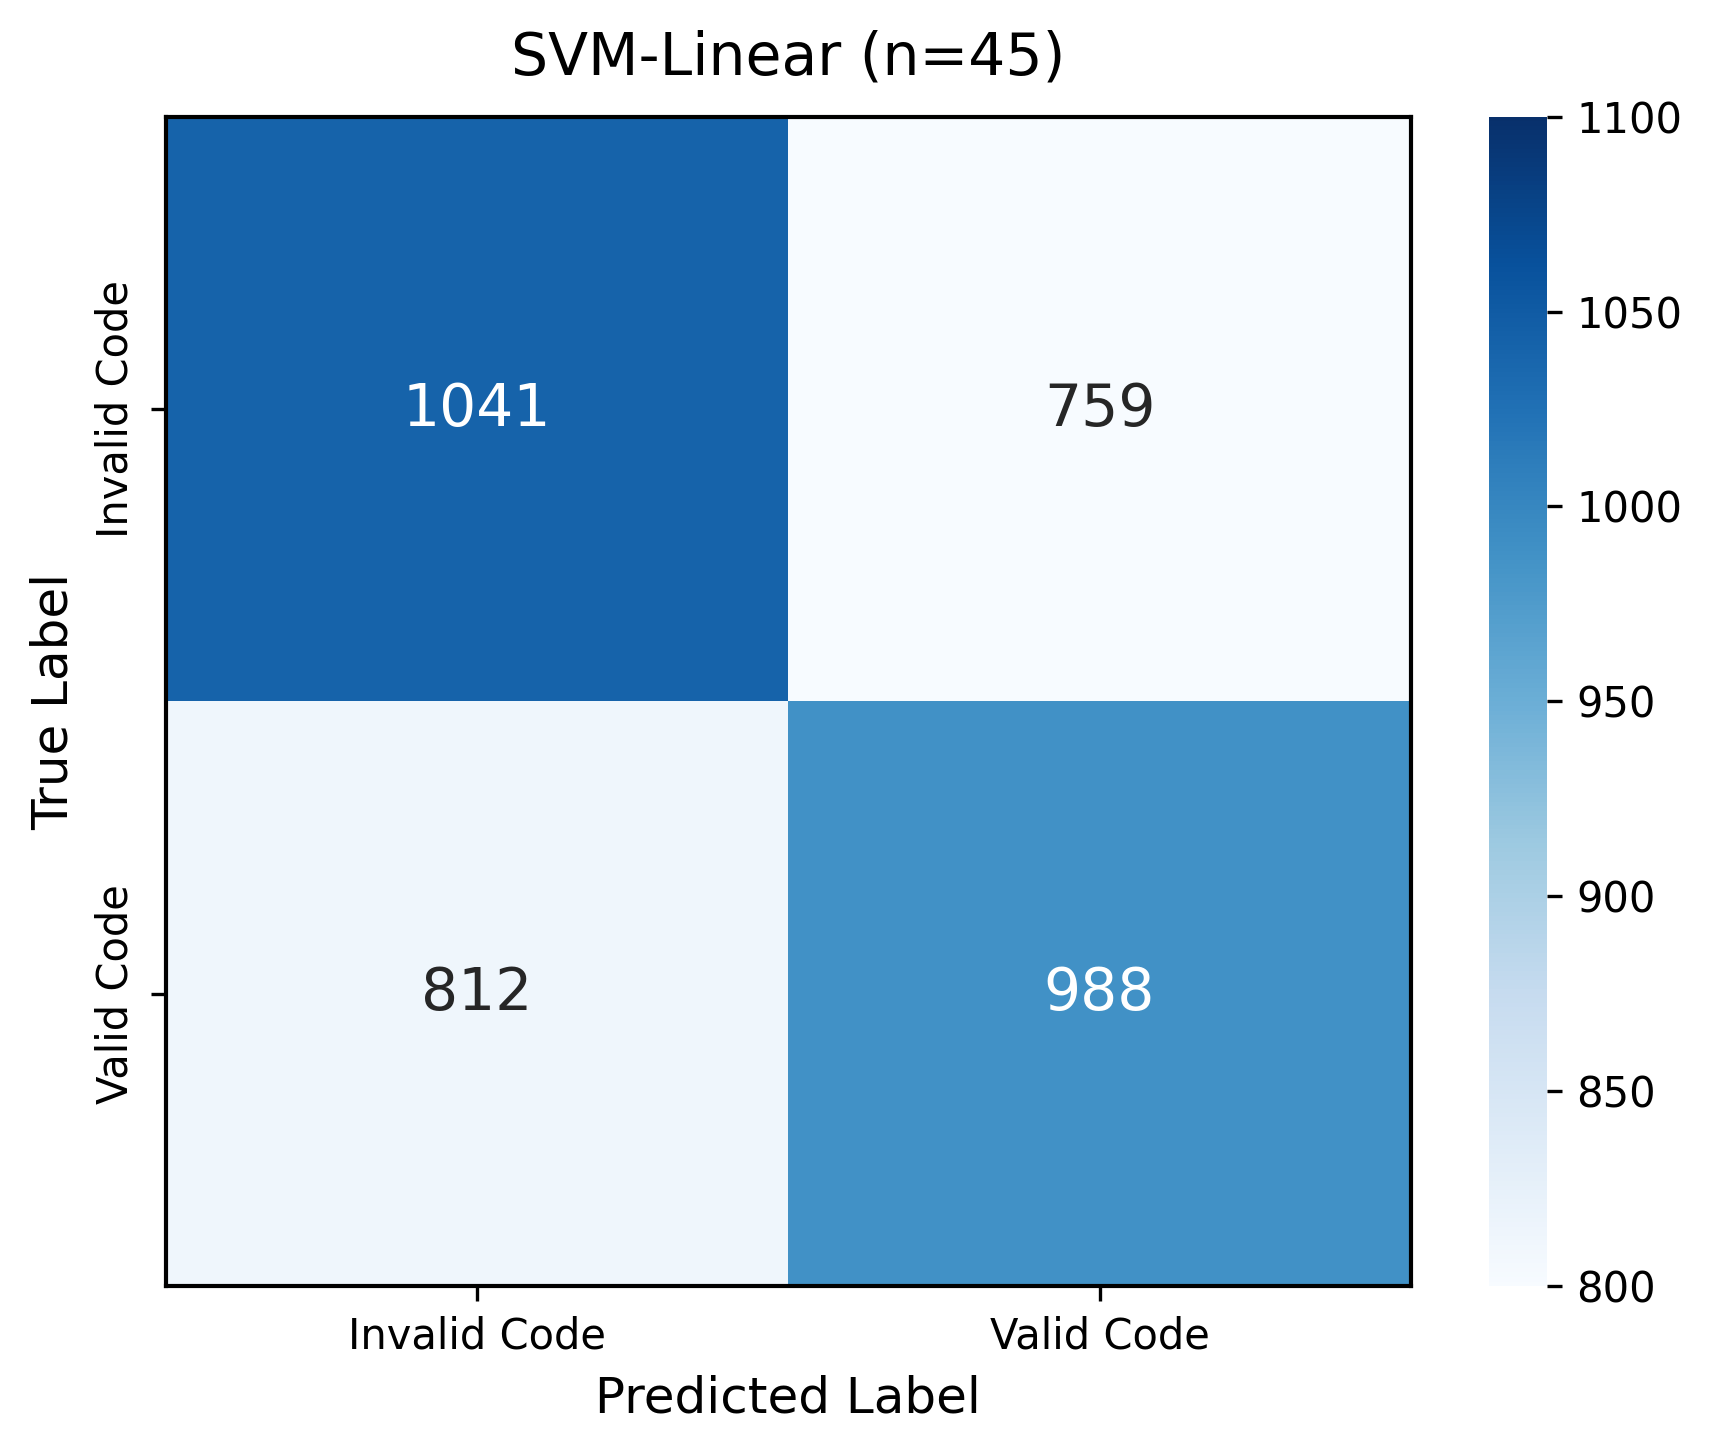

Model: SVM-RBF | Final Array Shape: (2, 2) | Subjects: 45


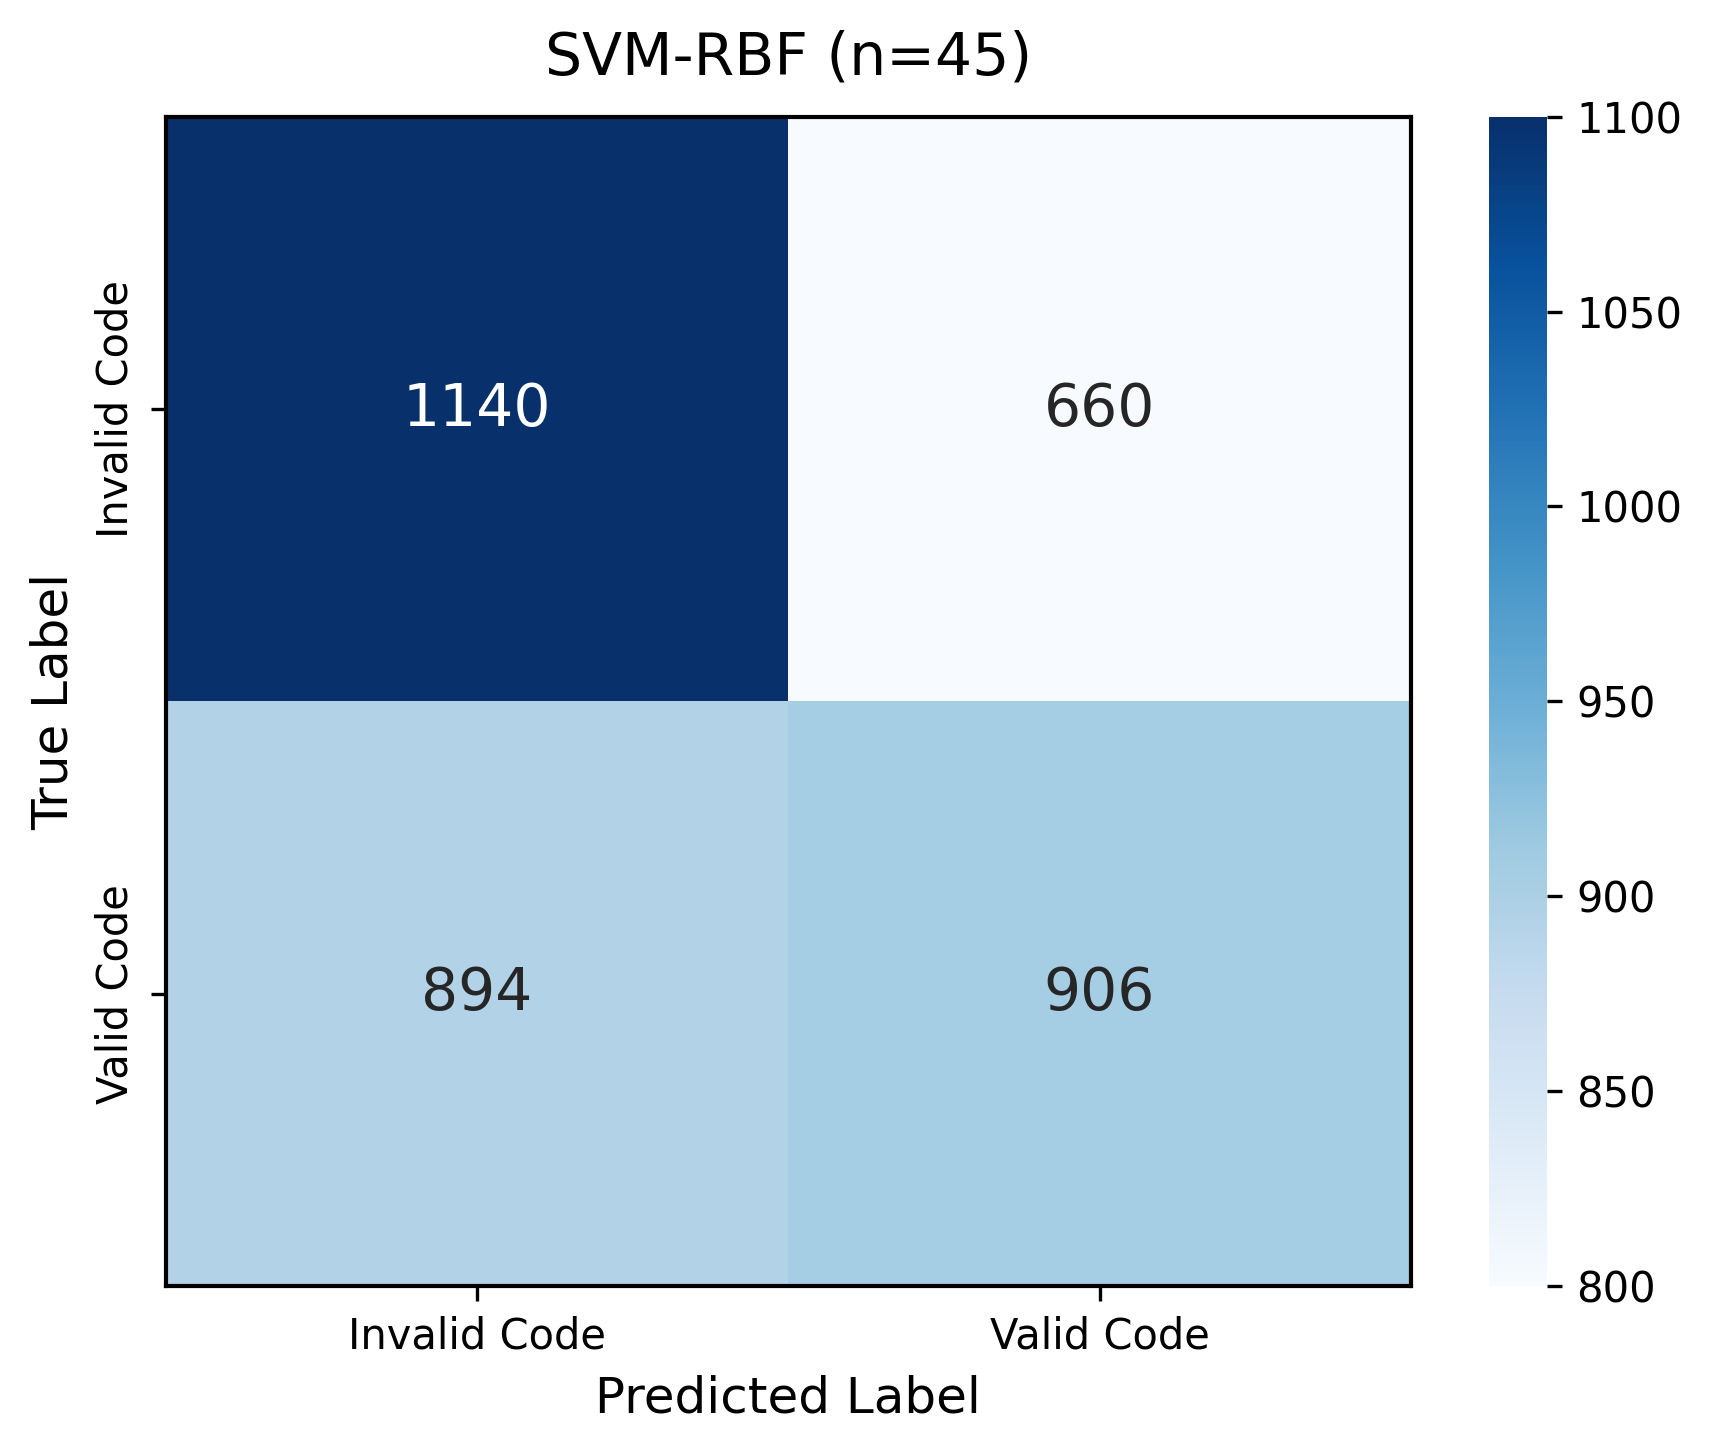

Model: Random Forest | Final Array Shape: (2, 2) | Subjects: 45


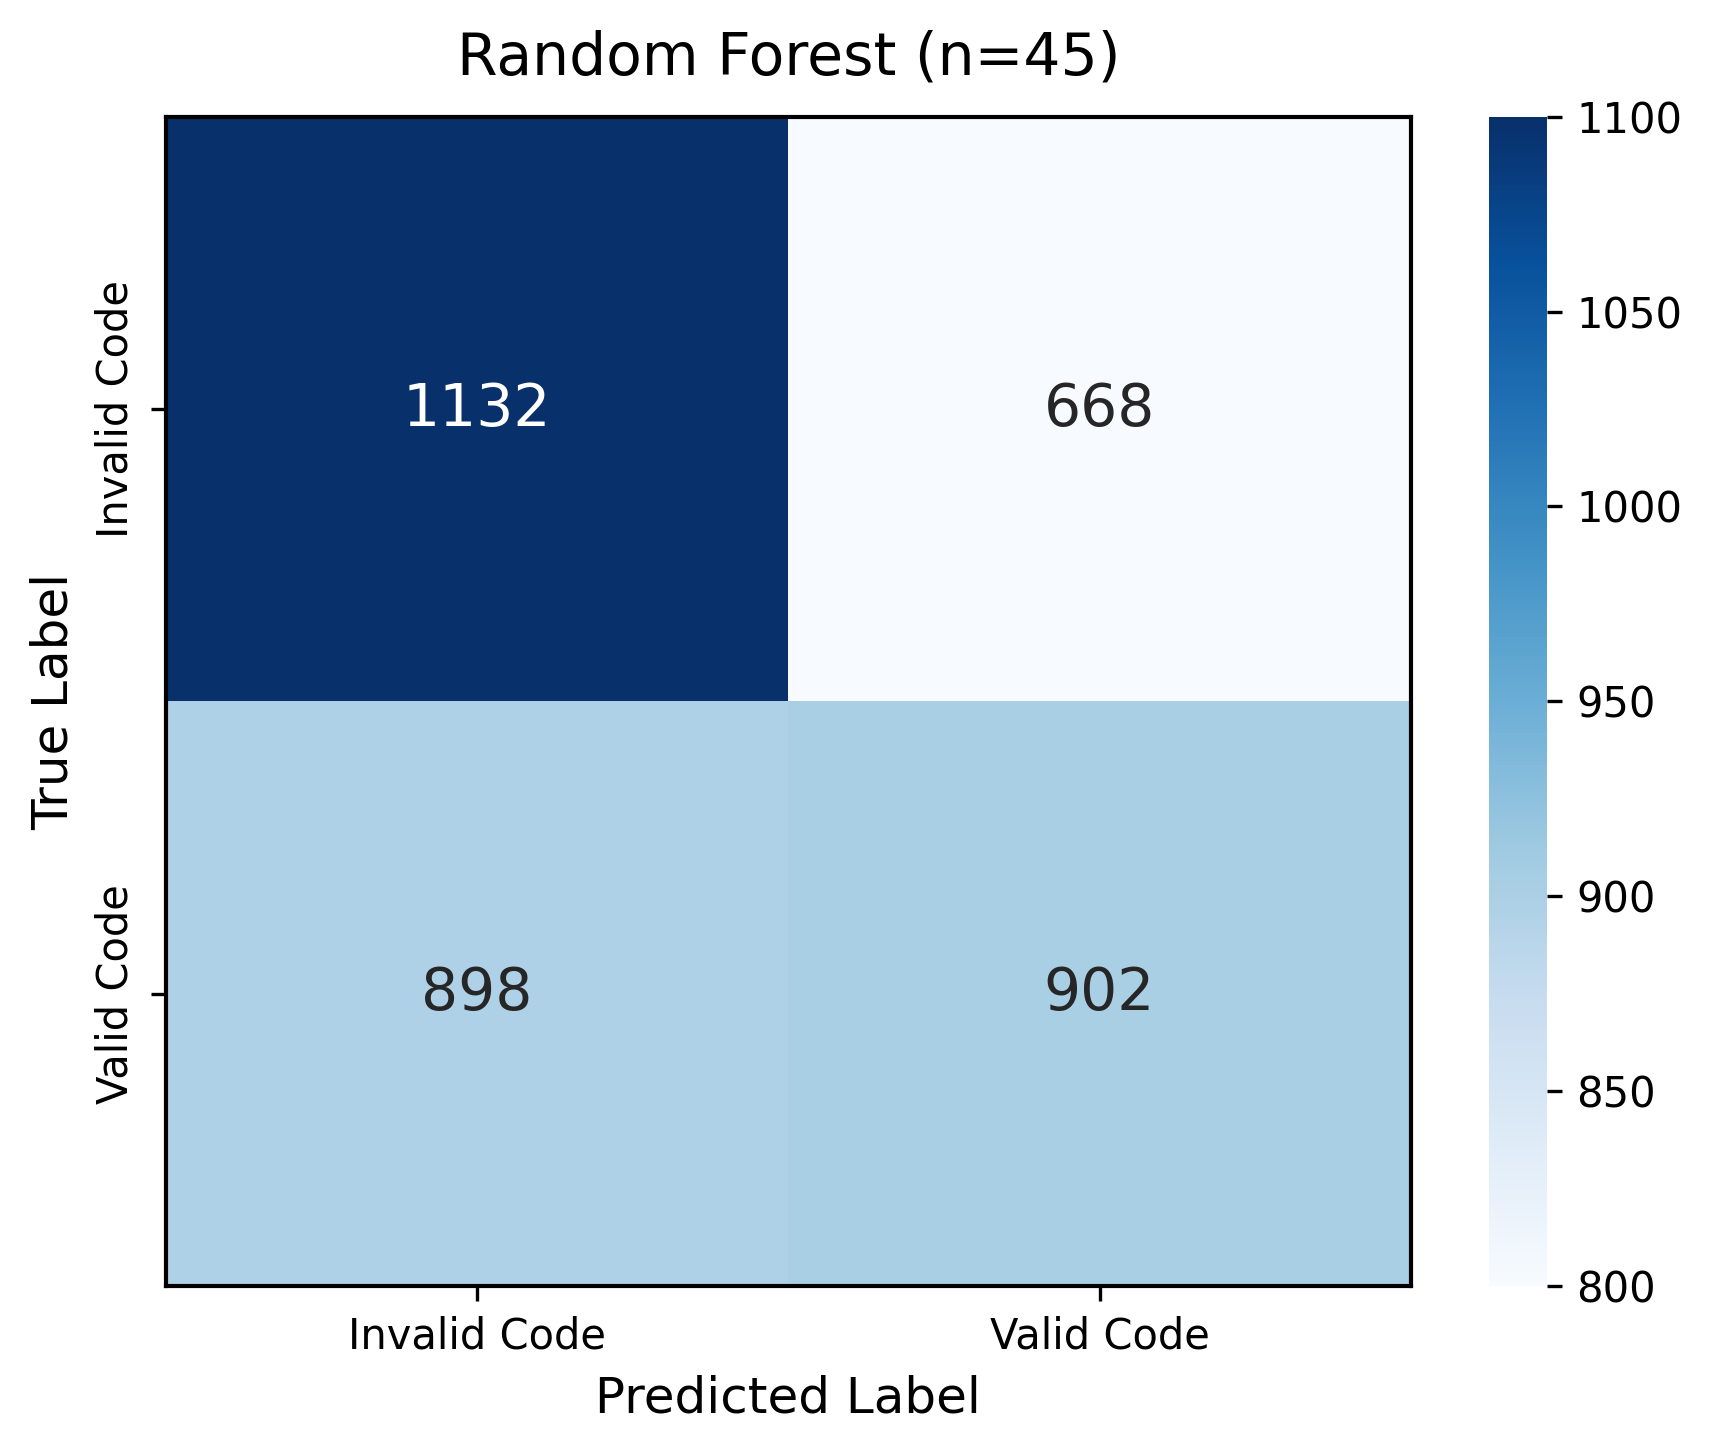

Model: MLP | Final Array Shape: (2, 2) | Subjects: 45


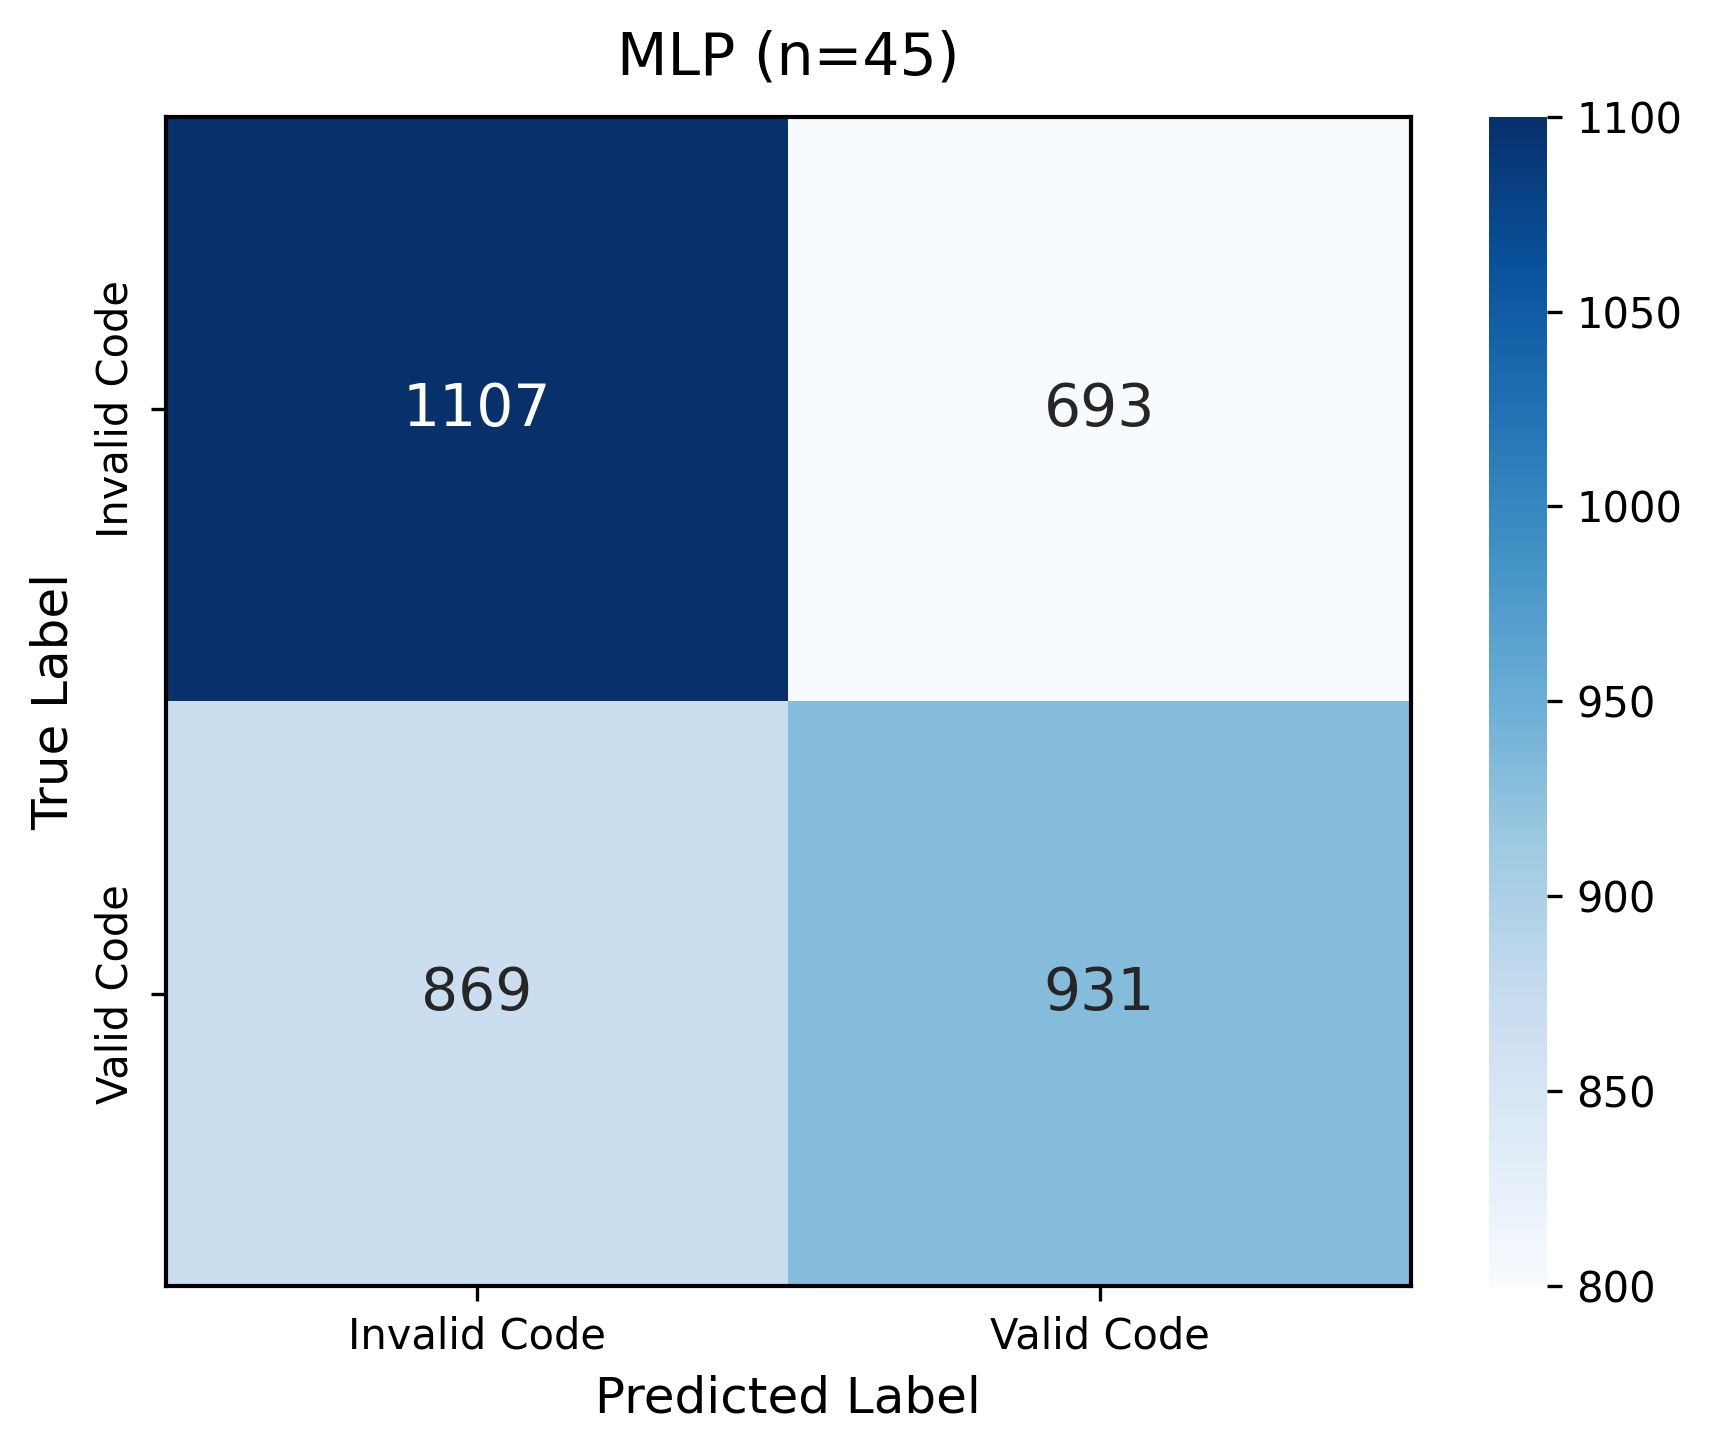

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_individual_inter_cms(viz_dict, save_dir, cohort='Global'):
    if cohort not in viz_dict:
        print(f"Error: Cohort '{cohort}' not found in visualization data.")
        return

    models_dict = viz_dict[cohort]
    class_labels = ['Invalid Code', 'Valid Code']

    print(f"--- Generating Individual Confusion Matrices for {cohort} Cohort ---")

    for model_name, metrics in models_dict.items():
        cm_raw = metrics.get('confusion_matrix')

        if cm_raw is not None:
            cm_raw = np.array(cm_raw)

            # extraxcting n subjects from the cm array
            cv_scores = metrics.get('cv_scores', [])
            n_subjects = len(cv_scores) if len(cv_scores) > 0 else "Unknown"

            print(f"Model: {model_name} | Final Array Shape: {cm_raw.shape} | Subjects: {n_subjects}")

            # SETUP OF THE FIGURE
            fig, ax = plt.subplots(figsize=(6, 5))

            # PLOTTING THE HEAT MAP
            sns.heatmap(cm_raw, annot=True, fmt='.0f', cmap='Blues', cbar=True,
                        xticklabels=class_labels, yticklabels=class_labels,
                        ax=ax, annot_kws={'size': 14},
                        vmin=800, vmax=1100,
                        cbar_kws={'ticks': [800, 850, 900, 950, 1000, 1050, 1100]})

            # formatting
            ax.set_title(f"{model_name} (n={n_subjects})", fontsize=14, pad=10)
            ax.set_ylabel('True Label')
            ax.set_xlabel('Predicted Label')

            # add border
            for _, spine in ax.spines.items():
                spine.set_visible(True)
                spine.set_color('black')
                spine.set_linewidth(1)

            plt.tight_layout()

            # EXPORT
            fig_path = os.path.join(save_dir, f"CM_cross-sub_{model_name.replace(' ', '_')}.png")
            fig.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.show()

        else:
            print(f"Warning: No confusion matrix data found for {model_name}.")

# EXECUTING THE FUNCTION
plot_individual_inter_cms(viz_data, FIG_DIR, cohort='Global')

## 4. Fold-Variance ROC-AUC Curves

--- Generating Individual ROC-AUC Curves for Global Cohort ---



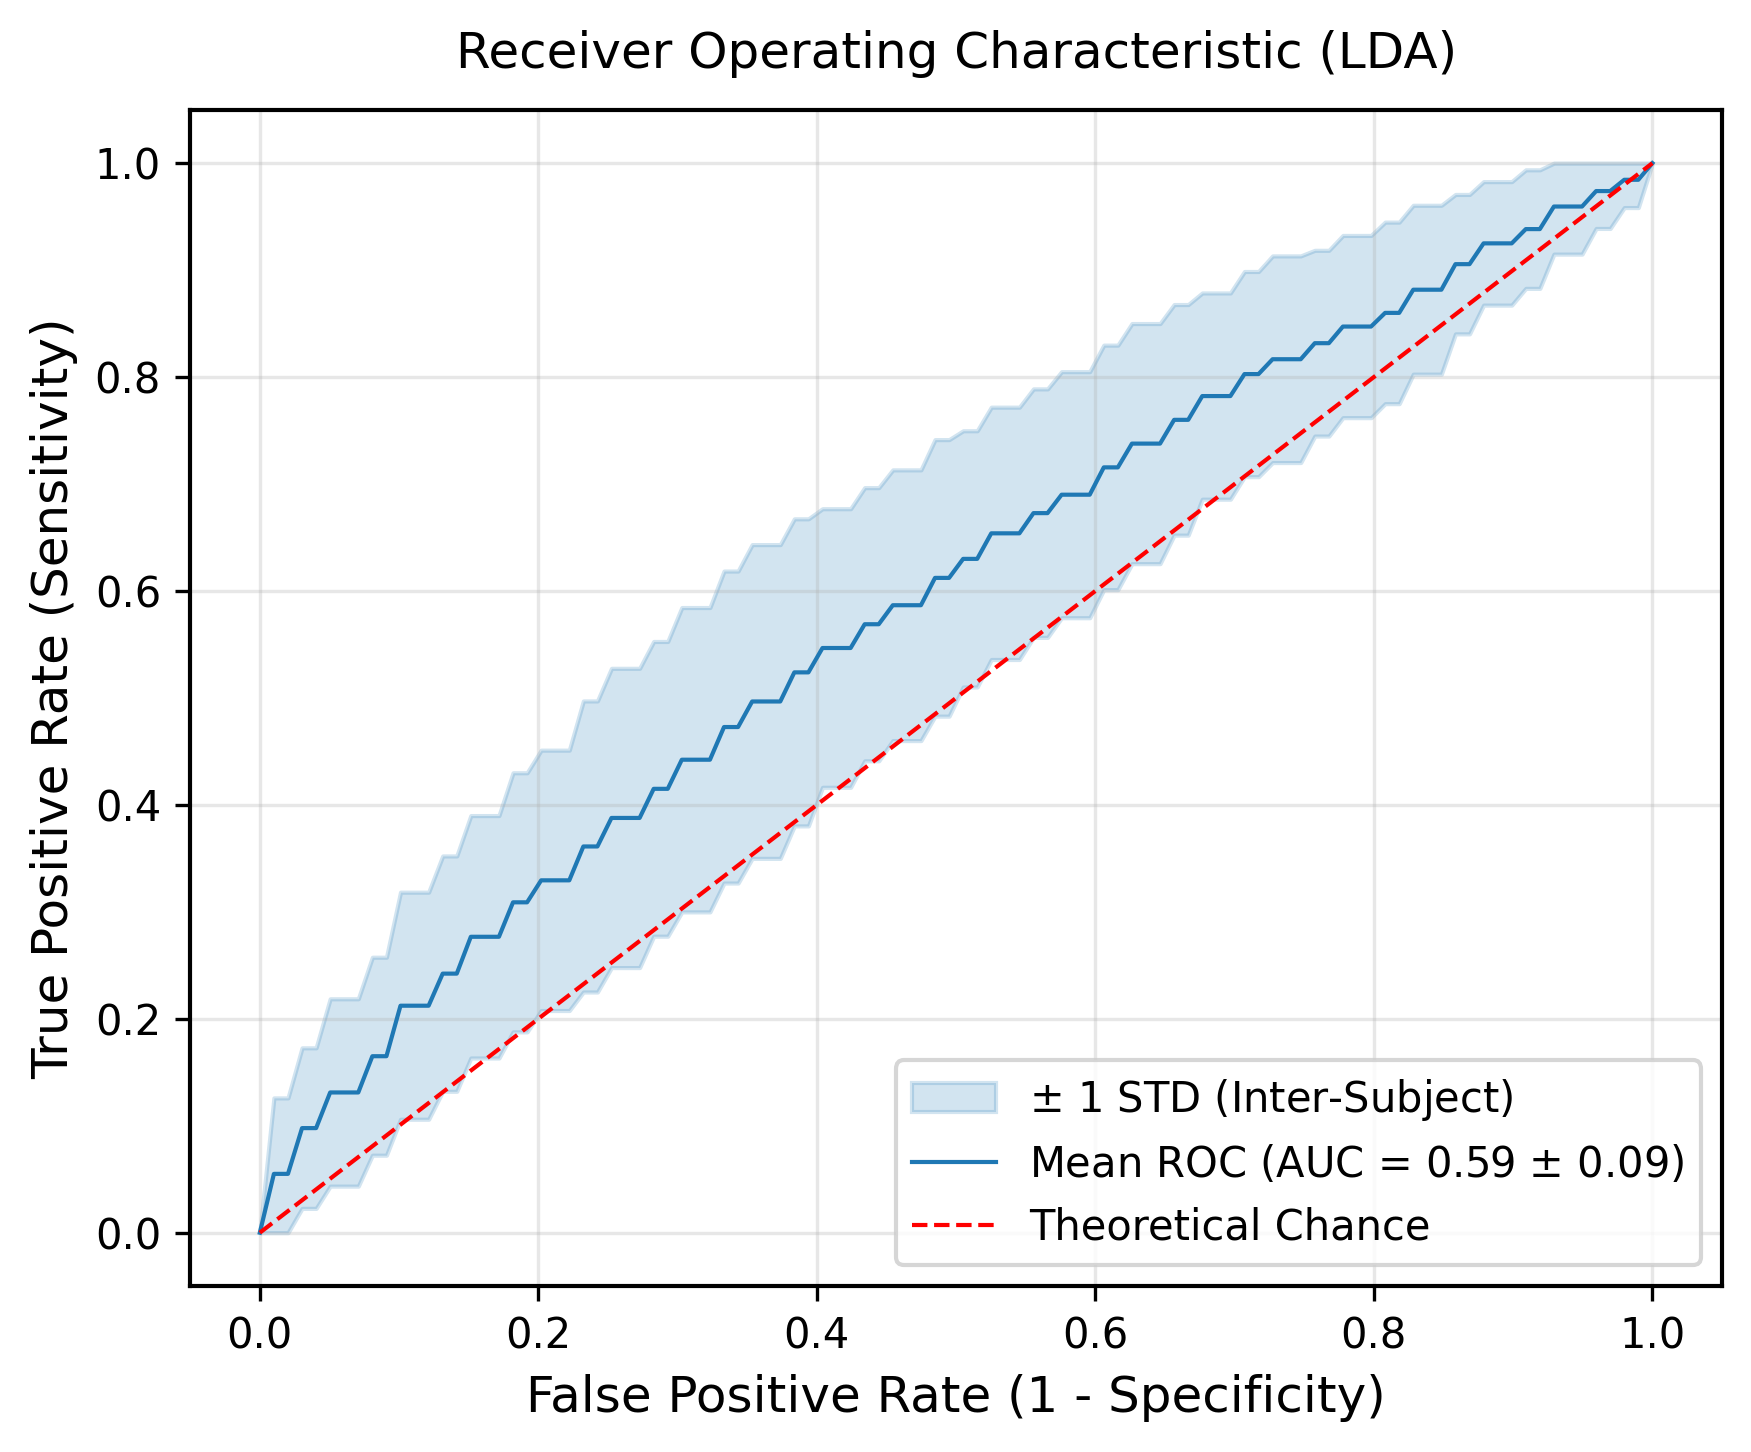

Saved Fold-Variance ROC curve to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/figures/ROC_Inter_LDA.png



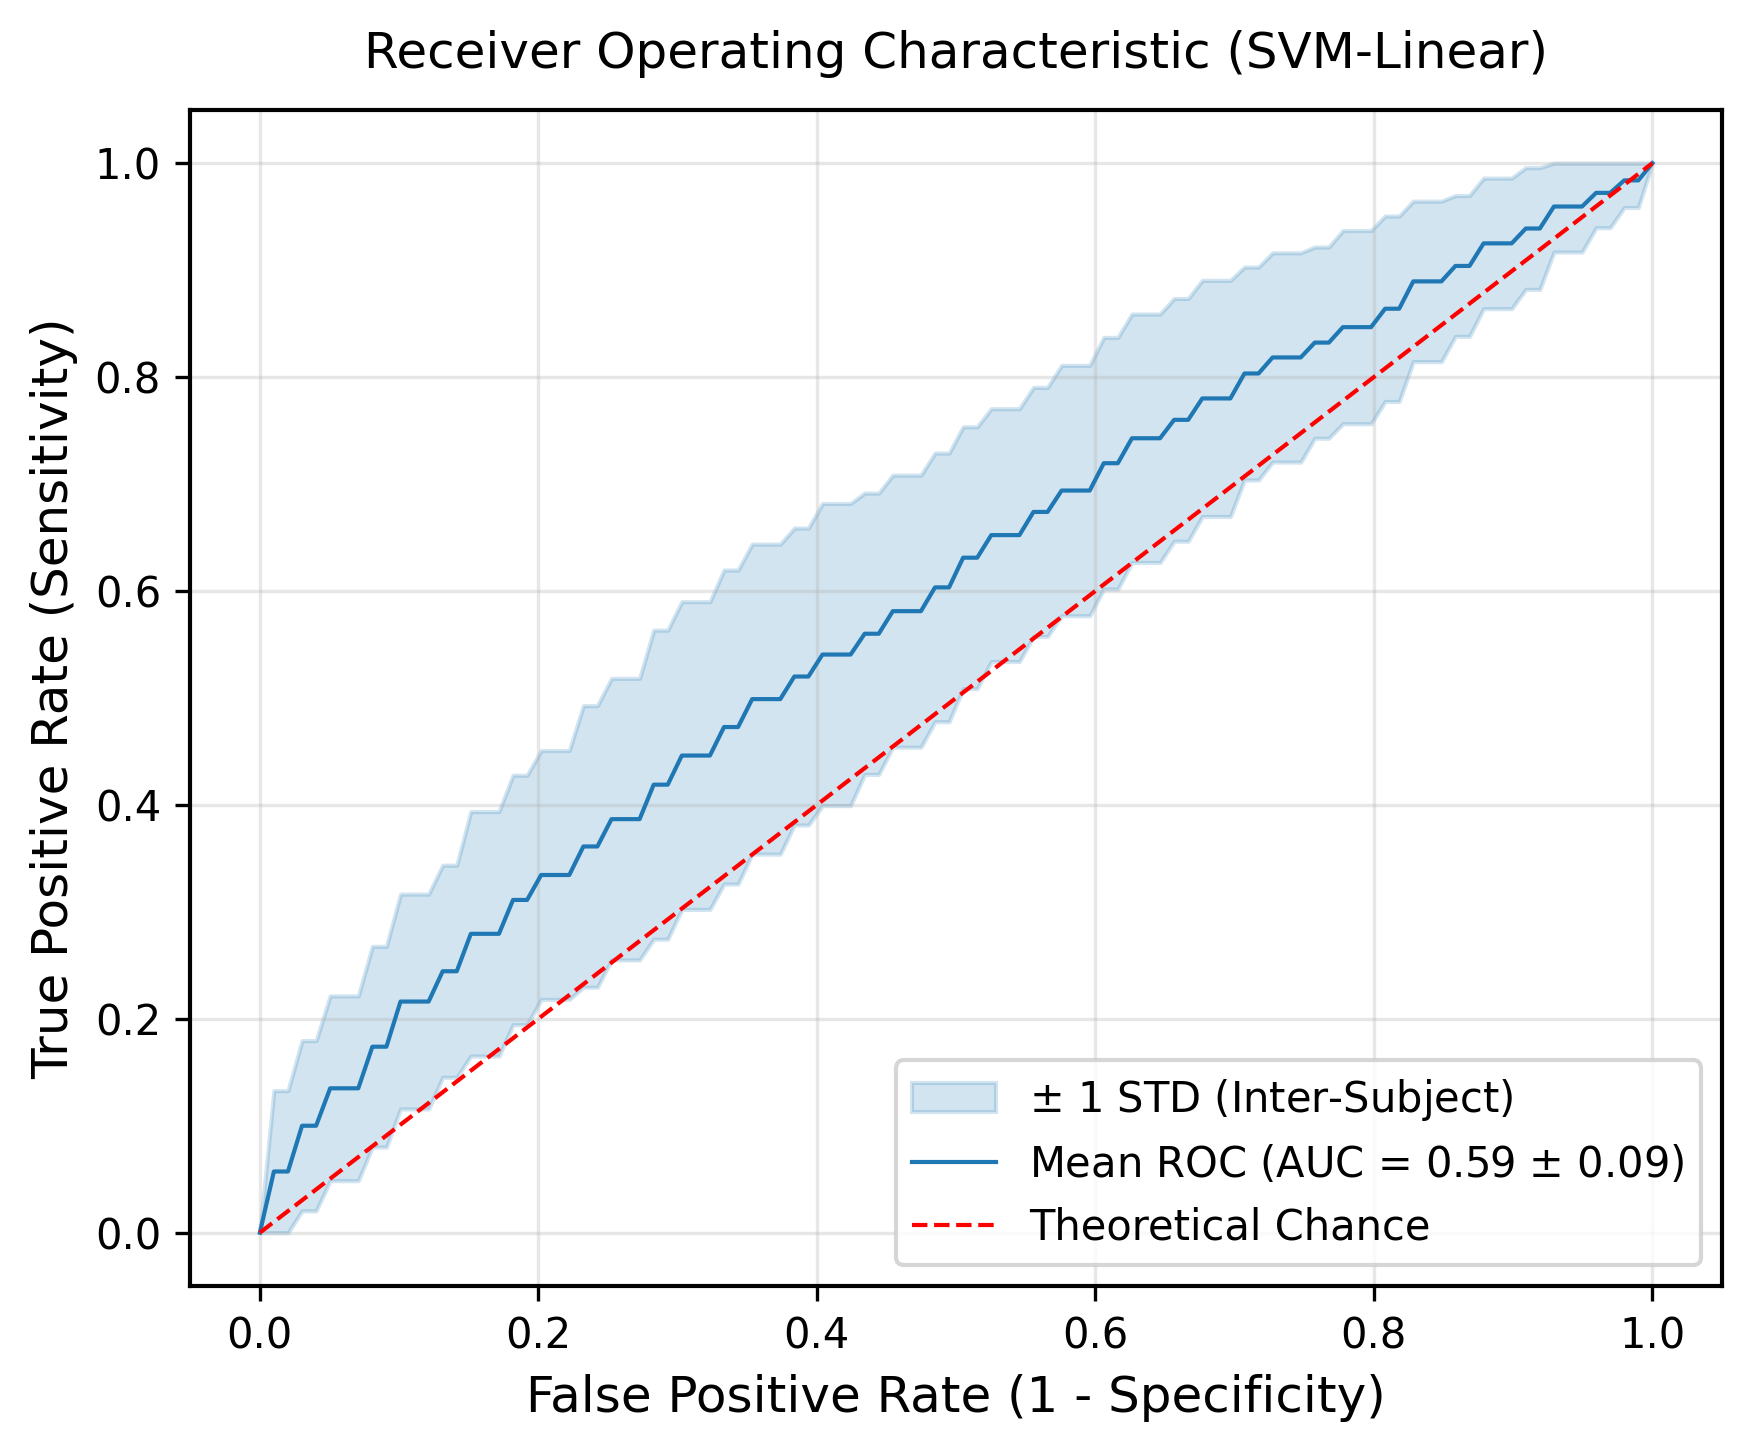

Saved Fold-Variance ROC curve to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/figures/ROC_Inter_SVM-Linear.png



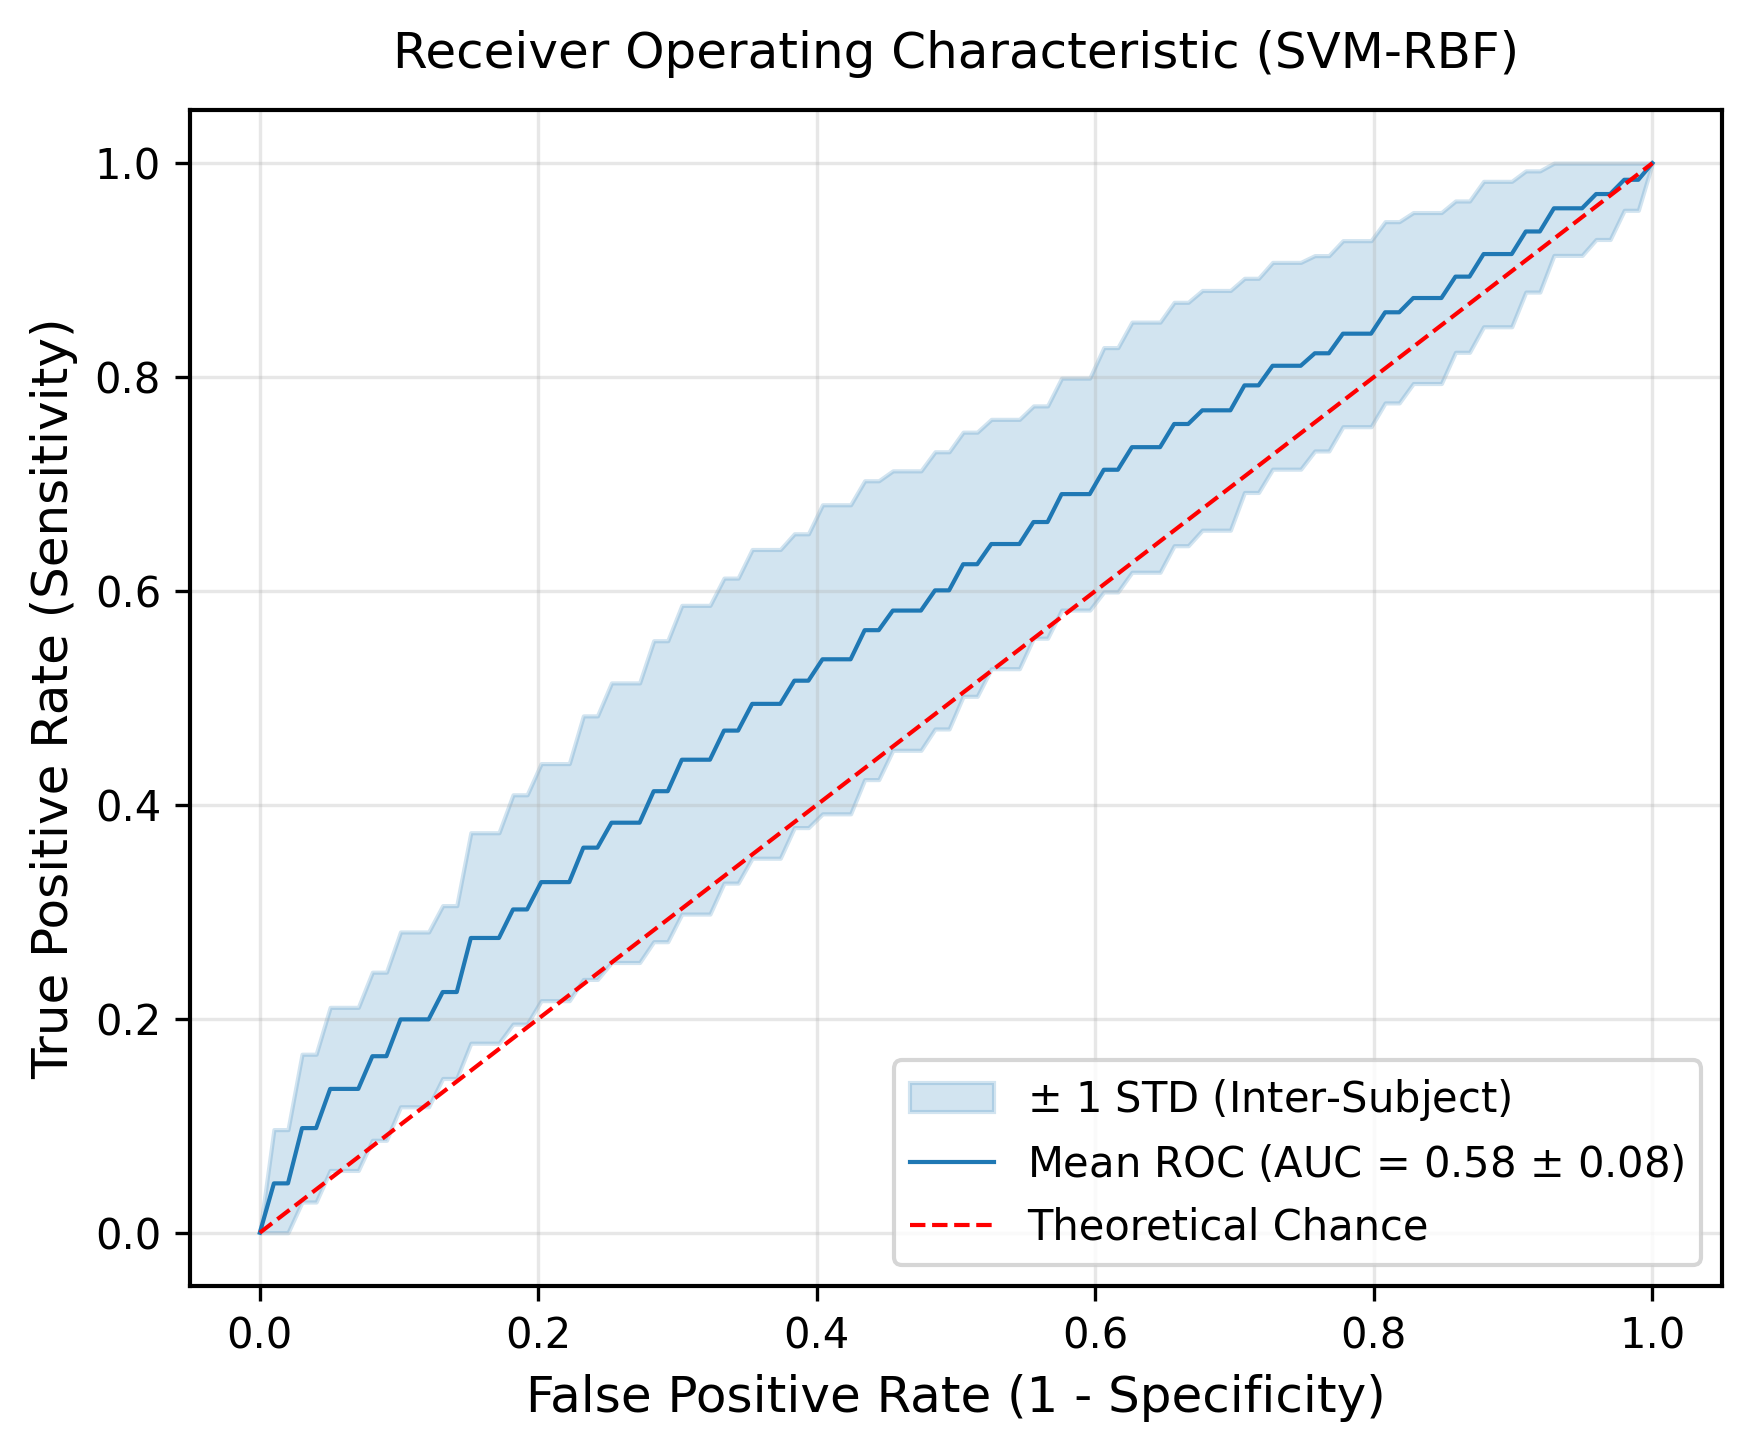

Saved Fold-Variance ROC curve to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/figures/ROC_Inter_SVM-RBF.png



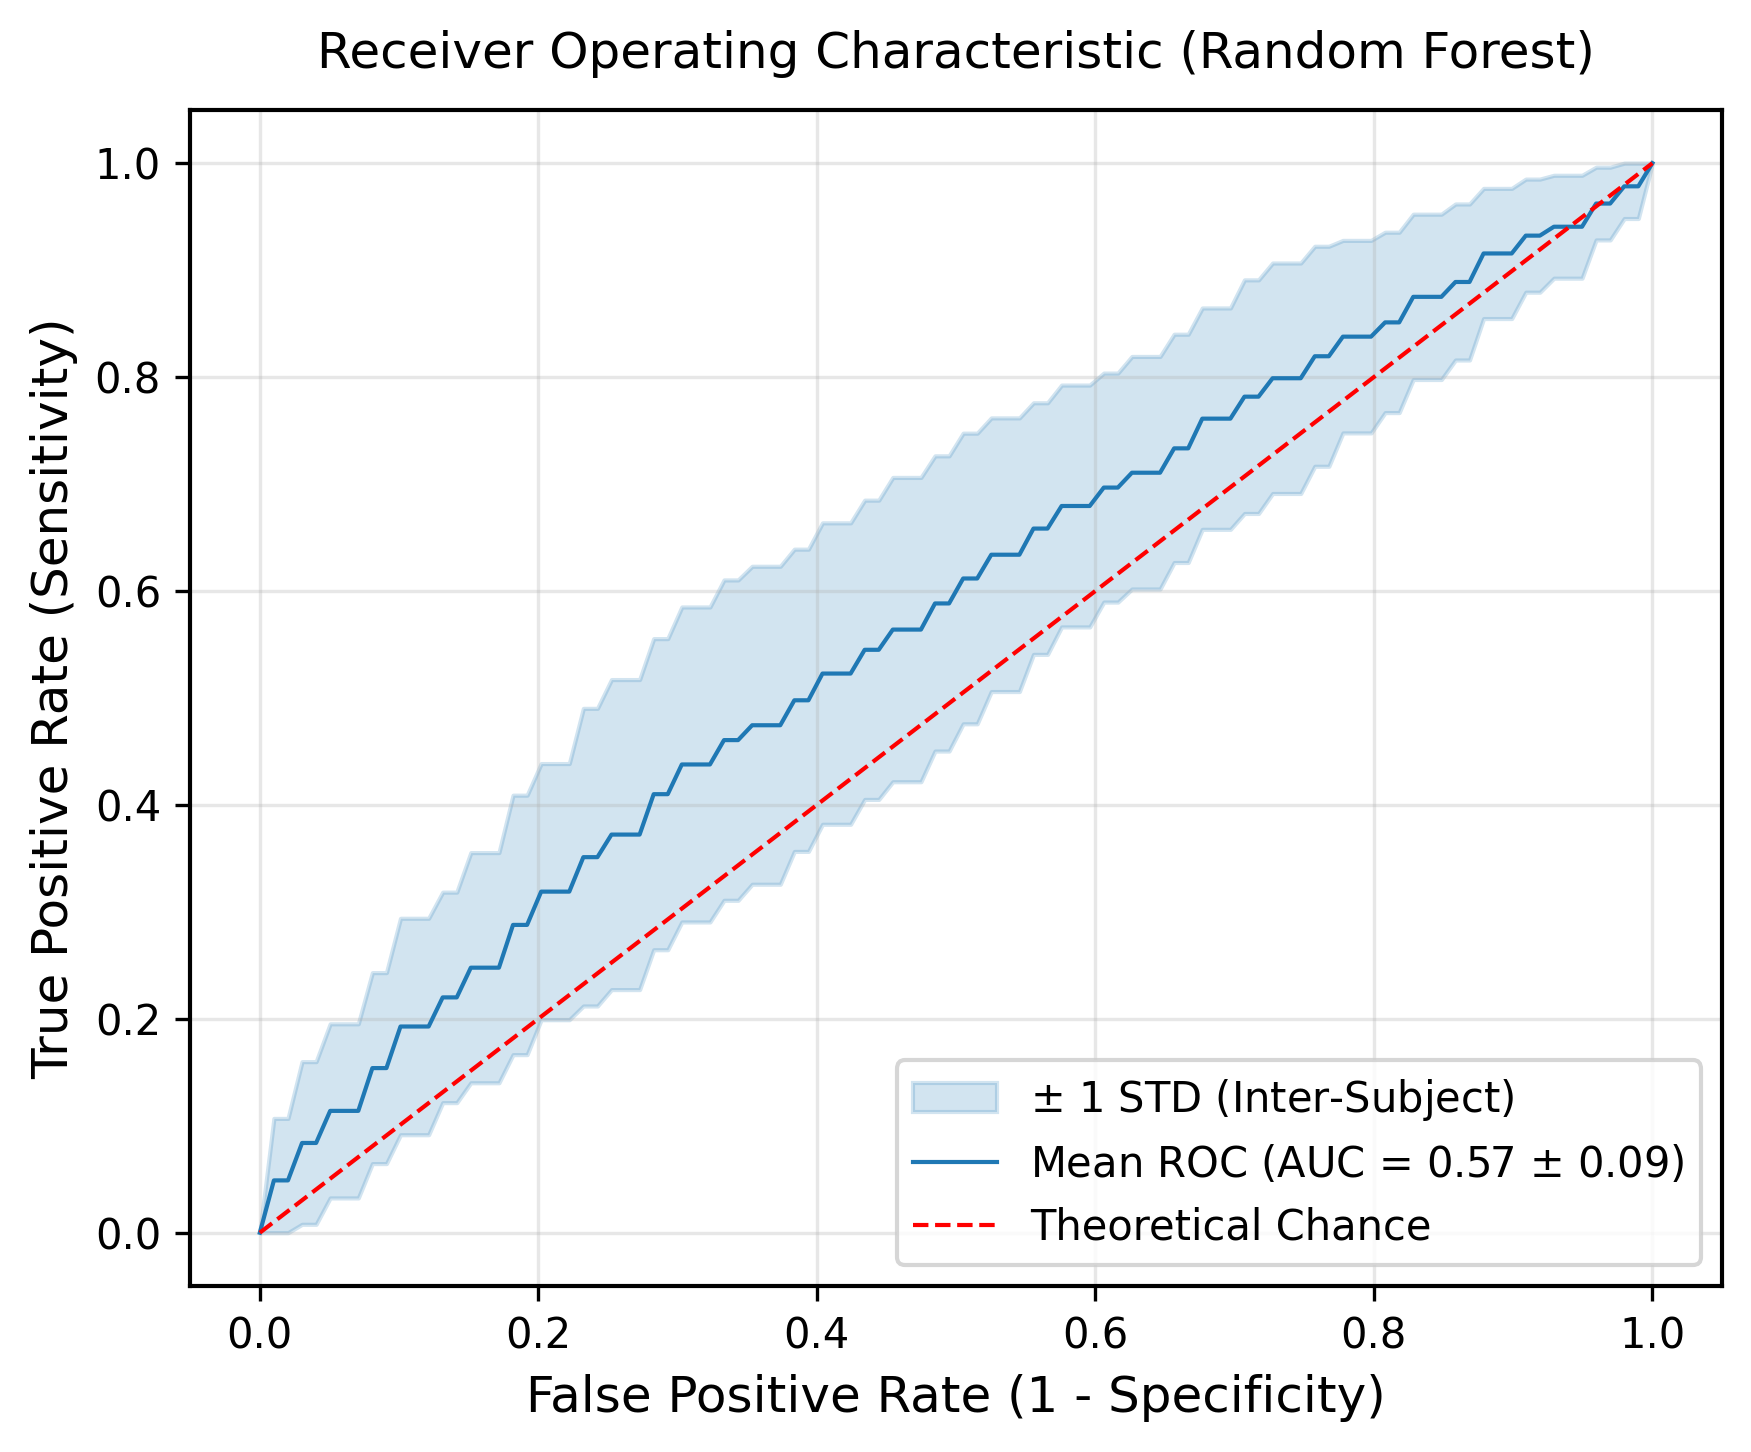

Saved Fold-Variance ROC curve to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/figures/ROC_Inter_Random_Forest.png



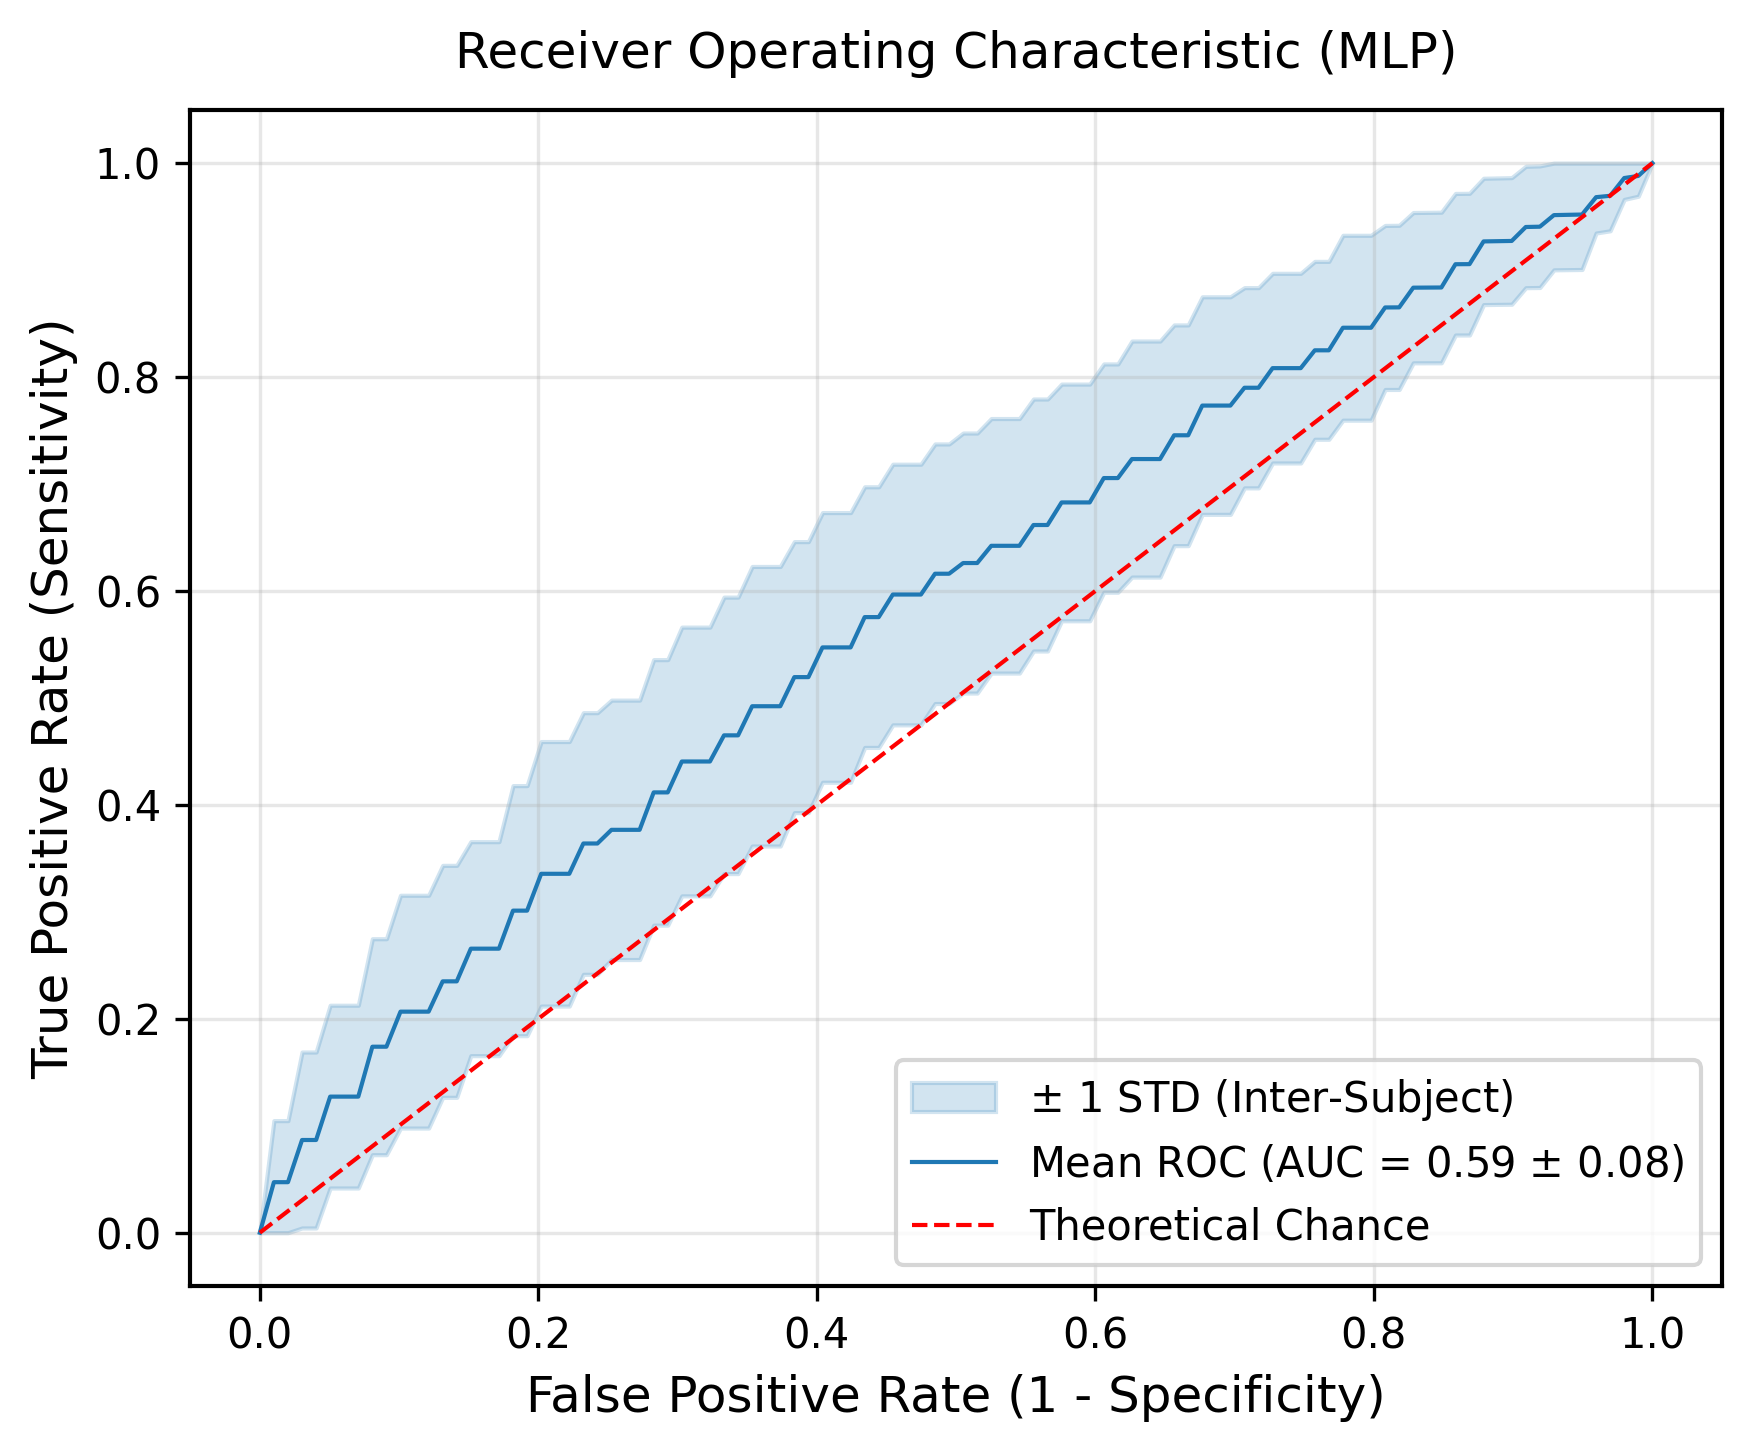

Saved Fold-Variance ROC curve to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/figures/ROC_Inter_MLP.png



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve, auc

def plot_individual_fold_variance_roc(viz_dict, save_dir, cohort='Global'):
    if cohort not in viz_dict:
        print(f"Error: Cohort '{cohort}' not found.")
        return

    models_dict = viz_dict[cohort]
    models = ['LDA', 'SVM-Linear', 'SVM-RBF', 'Random Forest', 'MLP']

    # color
    line_color = '#1f78b4'

    print(f"--- Generating Individual ROC-AUC Curves for {cohort} Cohort ---\n")

    for model_name in models:
        if model_name in models_dict:
            metrics = models_dict[model_name]
            y_true = np.array(metrics.get('y_true'))
            y_score = np.array(metrics.get('y_score'))
            subject_ids = np.array(metrics.get('subject_ids'))

            mean_fpr = np.linspace(0, 1, 100)
            tprs = []
            aucs = []

            unique_subjects = np.unique(subject_ids)
            valid_folds = 0

            # computing ROC for each subject
            for sub in unique_subjects:
                idx = (subject_ids == sub)
                fold_y_true = y_true[idx]
                fold_y_score = y_score[idx]

                if len(np.unique(fold_y_true)) > 1:
                    fpr, tpr, _ = roc_curve(fold_y_true, fold_y_score)
                    interp_tpr = np.interp(mean_fpr, fpr, tpr)
                    interp_tpr[0] = 0.0
                    tprs.append(interp_tpr)
                    aucs.append(auc(fpr, tpr))
                    valid_folds += 1

            if valid_folds == 0:
                print(f"Skipping {model_name}: Not enough valid folds for ROC.")
                continue

            # computing mean and std
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            mean_auc = auc(mean_fpr, mean_tpr)
            std_auc = np.std(aucs)
            std_tpr = np.std(tprs, axis=0)

            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

            # setup
            fig, ax = plt.subplots(figsize=(6, 5))

            ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color=line_color, alpha=0.2,
                            label=r'$\pm$ 1 STD (Inter-Subject)')

            # ROC LINE
            ax.plot(mean_fpr, mean_tpr, color=line_color, lw=1.0,
                    label=rf'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})')

            # CHANCE LINE
            ax.plot([0, 1], [0, 1], linestyle='--', lw=1.0, color='red', label='Theoretical Chance')

            # formatting
            ax.set_title(f"Receiver Operating Characteristic ({model_name})", fontsize=12, fontweight='normal', pad=10)
            ax.set_xlabel('False Positive Rate (1 - Specificity)', fontweight='normal')
            ax.set_ylabel('True Positive Rate (Sensitivity)', fontweight='normal')

            # setting up the axes and grid
            ax.set_xlim([-0.05, 1.05])
            ax.set_ylim([-0.05, 1.05])
            ax.grid(alpha=0.3)
            ax.legend(loc="lower right")

            for _, spine in ax.spines.items():
                spine.set_linewidth(1.0)

            plt.tight_layout()

            # EXPORT
            fig_path = os.path.join(save_dir, f"ROC_Inter_{model_name.replace(' ', '_')}.png")
            fig.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.show()

            print(f"Saved Fold-Variance ROC curve to: {fig_path}\n")

# EXECUTING THE FUNCTION
plot_individual_fold_variance_roc(viz_data, FIG_DIR, cohort='Global')

## 5. Spatial Pattern Topography

In [ ]:
!pip install -q mne scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 63.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import os
import glob
import pandas as pd
import mne
import matplotlib.pyplot as plt

print("--- Step 1: Loading Metadata & Extracting Montage ---")

# 1. Define Paths
DATA_DIR = '/content/drive/MyDrive/EEG_data/full_subject_list'
INTER_DIR = '/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data'
FIG_DIR = os.path.join(INTER_DIR, 'figures')

tsv_path = os.path.join(DATA_DIR, 'participants.tsv')

--- Step 1: Loading Metadata & Extracting Montage ---


Targeting reference subject: sub-001
Loading metadata from: sub-001_task-PY_eeg.set


/tmp/ipykernel_7802/2605310119.py:29: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(reference_set_file, verbose=False)


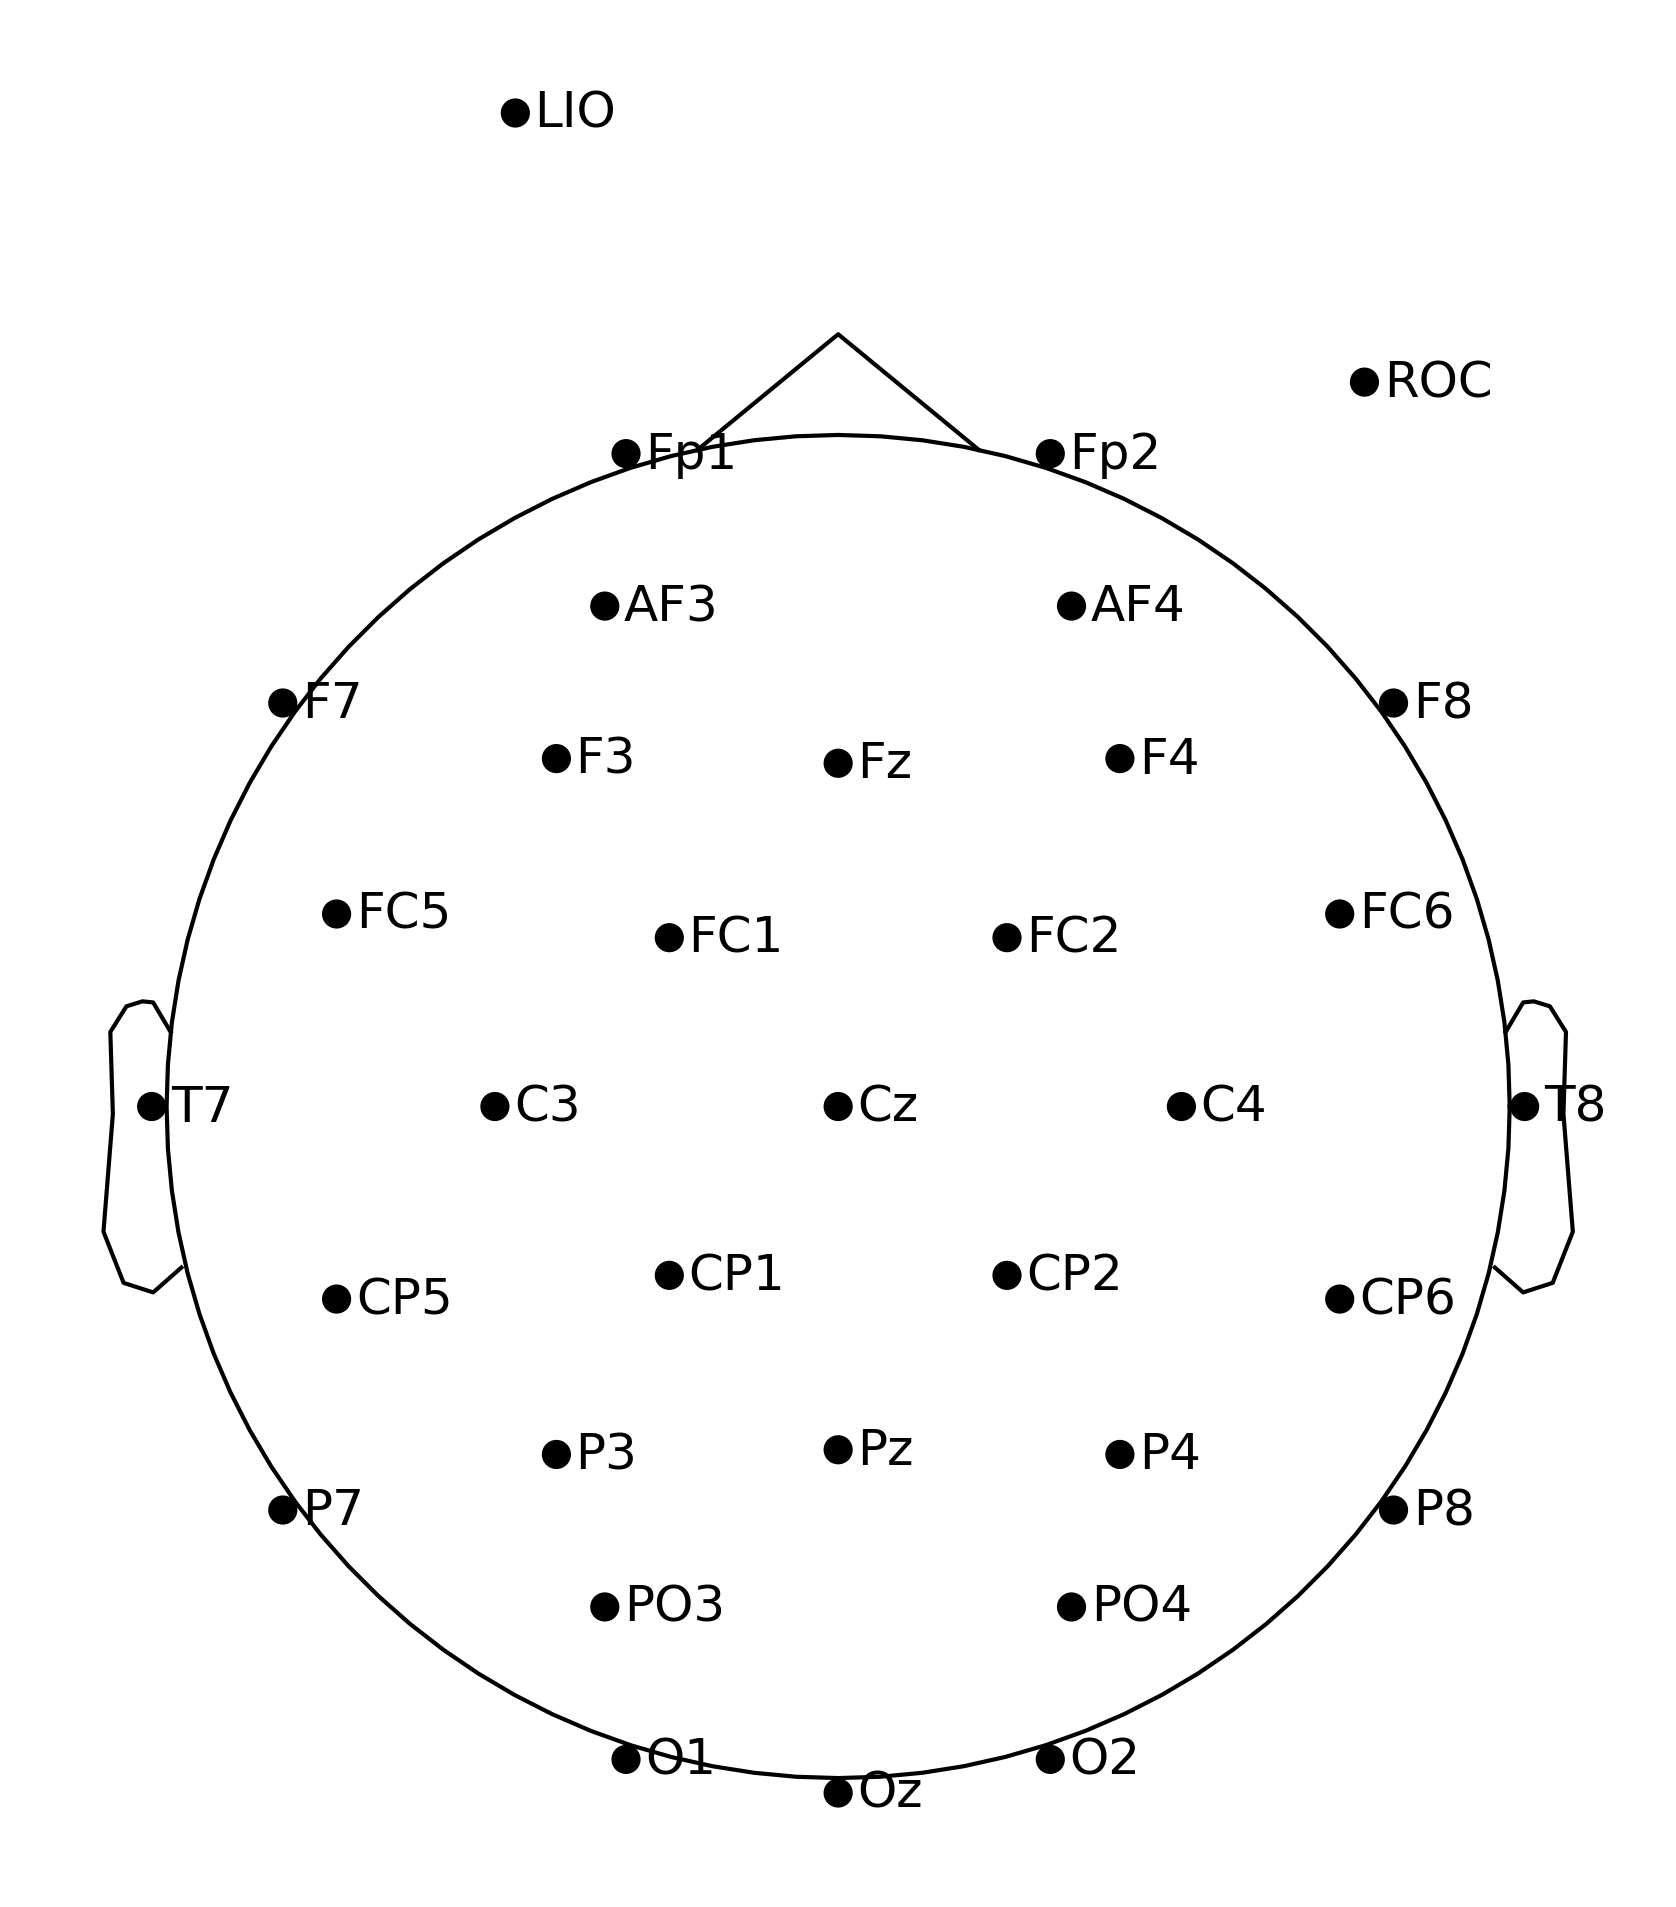


SUCCESS: Extracted info object with 34 channels.
Saved Sensor Layout to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/figures/electrode_layout.png


In [ ]:
import os
import pandas as pd
import mne
import glob
import matplotlib.pyplot as plt


try:
    # loading metadata
    df_participants = pd.read_csv(tsv_path, sep='\t')
    first_valid_sub = str(df_participants['participant_id'].iloc[0])

    if not first_valid_sub.startswith('sub-'):
        first_valid_sub = f"sub-{first_valid_sub}"

    print(f"Targeting reference subject: {first_valid_sub}")

    # locating the .set file
    search_pattern = os.path.join(DATA_DIR, first_valid_sub, 'eeg', '*.set')
    set_files = glob.glob(search_pattern)

    if not set_files:
        print(f"CRITICAL ERROR: No .set file found using pattern: {search_pattern}")
    else:
        reference_set_file = set_files[0]
        print(f"Loading metadata from: {os.path.basename(reference_set_file)}")

        # READING THE EEGLAB EPOCH
        epochs = mne.io.read_epochs_eeglab(reference_set_file, verbose=False)
        eeg_info = epochs.info

        # PLOTTING the sensor topography (2D Scalp Map)
        fig, ax = plt.subplots(figsize=(8, 8))
        mne.viz.plot_sensors(eeg_info, show_names=True, kind='topomap', axes=ax, sphere='auto')
        ax.set_title('Standardized EEG Sensor Layout (Kuo & Prat, 2023)', fontweight='bold', fontsize=14, pad=15)

        # EXPORTING
        sensor_fig_path = os.path.join(FIG_DIR, 'electrode_layout.png')
        fig.savefig(sensor_fig_path, dpi=300, bbox_inches='tight', facecolor='white')

        plt.show()

        print(f"\nSUCCESS: Extracted info object with {len(eeg_info.ch_names)} channels.")
        print(f"Saved Sensor Layout to: {sensor_fig_path}")

except FileNotFoundError:
    print(f"CRITICAL ERROR: Could not find participants.tsv at {tsv_path}. Check Google Drive mount.")